# Girl with a Pearl Earring: GA Image Approximation

This notebook documents the CIFO project: approximating Vermeer's *Girl with a Pearl Earring* (300x400 px) using a Genetic Algorithm that evolves a population of 100 triangles, minimising pixel-level RMSE.

Pipeline code is referenced via **links to the source `.py` files**. Click any link to open the file directly.  
Results are loaded from **pre-computed JSON files** in executable cells.

**Group:** C07_Finch

**Group Members:**
- Carolina Luz (20250409)
- Giosuè Morelli (20250472)
- Diego Rocha (20210691)

**Additional challenge:** Challenge 3: Operators Contribution Analysis 

**Wow factor:** Island GA (4 subpopulations, ring-topology migration)

---

## Table of Contents

1. [Main Algorithms](#1-main-algorithms)
2. [Grid Search](#2-grid-search)
   - [2.1 Results Analysis](#21-results-analysis)
   - [2.2 Operators Contribution Analysis (Challenge 3)](#22-operators-contribution-analysis-challenge-3)
3. [Statistical Validation of the Best Configuration](#3-statistical-validation-of-the-best-configuration)
   - [3.1 Results Analysis](#31-results-analysis)
4. [Different Representation and Initialization Experiments](#4-different-representation-and-initialization-experiments)
   - [4.1 Alpha Transparency Factor](#41-alpha-transparency-factor)
   - [4.2 Coverage Initialization](#42-coverage-initialization)
   - [4.3 Results Analysis](#43-results-analysis)
5. [Probability Tuning](#5-probability-tuning-crossover-and-mutation)
   - [5.1 Results Analysis](#51-results-analysis)
6. [Final Run and Island GA Analysis](#6-final-run-and-island-ga-analysis)
   - [6.1 Final Configuration Run](#61-final-configuration-run)
   - [6.2 Island GA](#62-island-ga)
   - [6.3 Results Analysis](#63-results-analysis)

---

## Pipeline

```
Setup -> Grid Search -> Operator Analysis -> Statistical Validation -> Representation Experiments -> Probability Tuning -> Final Run -> Island GA
```

---

# 1. Main Algorithms

The core of the project lives in these three files. Each individual is a list of 100 triangles, each defined by 9 floats: `[x1, y1, x2, y2, x3, y3, R, G, B]`, so the genome is **900 values** in total.

This section introduces the foundational building blocks that every experiment in this notebook builds on: the triangle representation, the rendering pipeline, the fitness function, and the core GA loop.

> **[`render.py`](core/render.py)**  
*Takes a list of triangles (coordinates + RGB) and draws them onto a blank canvas, returning a PIL image.*

> **[`triangle_solution.py`](core/triangle_solution.py)**  
*Defines the problem: a solution is 100 random triangles, and fitness is the RMSE between the rendered image and the target painting.*

> **[`ga.py`](library/algorithms/geneticalgorithms/ga.py)**  
*Runs the genetic algorithm loop: selects parents, applies crossover and mutation, preserves the elite, and logs the best fitness each generation.*

---

# 2. Grid Search

Before touching probabilities or trying fancier representations, we needed to know which combination of selection, crossover, and mutation operators actually works for this problem.

Instead of guessing, we ran a full factorial grid search, fix everything else, vary only the operators, and let the results speak.

The fixed hyperparameters are `pop=80`, `gen=800`, `xo_prob=0.7`, `mut_prob=0.05`, `elitesize=2`.

> Clicking on the operator category component in the table below will open the corresponding script.

| Component | Operators | Count |
|-----------|-----------|-------|
| **[`selection.py`](library/algorithms/geneticalgorithms/selection.py)**  | roulette, rank, tournament k=2, k=3, k=5 | 5 |
| **[`crossover.py`](library/algorithms/geneticalgorithms/crossover.py)**  | one-point, two-point, uniform | 3 |
| **[`mutation.py`](library/algorithms/geneticalgorithms/mutation.py)** | gaussian, random reset | 2 |
| **Total** | 5 × 3 × 2 × 10 runs | **300 runs** |

This script ran all 300 experiments in a crash-safe loop, saving one JSON log per run so we could stop and resume at any point, every script ran in this project follows this main schema:

> **[`run_standard_grid.py`](experiments/run_standard_grid.py)**  
*Builds all 30 operator combinations via build_grid(), runs each 10 times, and saves one JSON log plus one rendered image per run; already-completed runs are automatically skipped so the script can be safely interrupted and restarted.*

---

## 2.1 Results Analysis

#### Loading results

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

LOGS_DIR = Path('results/standard_grid/logs')
IMG_DIR  = Path('results/standard_grid/images')

records = []
for fpath in sorted(LOGS_DIR.glob('*.json')):
    d = json.loads(fpath.read_text(encoding='utf-8'))
    cid = d['config_id']
    parts = cid.split('__')
    sel = parts[0].replace('sel_', '')
    xo  = parts[1].replace('xo_', '')
    mut = parts[2].replace('mut_', '')
    records.append({
        'config_id':    cid,
        'selection':    sel,
        'crossover':    xo,
        'mutation':     mut,
        'run':          int(d['run']),
        'rmse_initial': float(d['rmse_initial']),
        'rmse_final':   float(d['rmse_final']),
        'rmse_gen200':  float(d['snapshots']['rmse_gen200']),
        'rmse_gen400':  float(d['snapshots']['rmse_gen400']),
        'rmse_gen600':  float(d['snapshots']['rmse_gen600']),
        'rmse_gen800':  float(d['snapshots']['rmse_gen800']),
        'elapsed_sec':  float(d['elapsed_sec']),
        'fitness_curve': d['fitness_curve'],
    })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} runs across {df["config_id"].nunique()} configs')
df[['selection','crossover','mutation','rmse_final','elapsed_sec']].head(10)

Loaded 300 runs across 30 configs


,selection,crossover,mutation,rmse_final,elapsed_sec
0,rank,one_point,gaussian,44.8089,84.0
1,rank,one_point,gaussian,46.1520,83.4
2,rank,one_point,gaussian,40.9773,84.9
3,rank,one_point,gaussian,44.5659,82.8
4,rank,one_point,gaussian,45.7615,82.8
5,rank,one_point,gaussian,42.8882,81.9
6,rank,one_point,gaussian,46.0960,81.7
7,rank,one_point,gaussian,44.9921,83.5
8,rank,one_point,gaussian,43.2783,83.6
9,rank,one_point,gaussian,42.5835,84.7


#### Top 5 configurations by mean RMSE

Tournament k=5 and gaussian mutation should lead, small refinements beat large random jumps at 800 generations.

In [2]:
summary = (
    df.groupby(['config_id', 'selection', 'crossover', 'mutation'])
    .agg(
        rmse_mean=('rmse_final', 'mean'),
        rmse_std =('rmse_final', 'std'),
        rmse_min =('rmse_final', 'min'),
        rmse_max =('rmse_final', 'max'),
    )
    .reset_index()
    .sort_values('rmse_mean')
    .reset_index(drop=True)
)
summary.index += 1

summary[['selection','crossover','mutation','rmse_mean','rmse_std','rmse_min','rmse_max']].head(5).round(4)

,selection,crossover,mutation,rmse_mean,rmse_std,rmse_min,rmse_max
1,tournament_k5,uniform,gaussian,38.1214,1.9169,34.4096,41.1856
2,tournament_k5,two_point,gaussian,38.8591,2.2894,35.4825,42.3088
3,tournament_k3,uniform,gaussian,39.0210,1.4602,36.9630,41.4405
4,tournament_k5,one_point,gaussian,39.7065,2.4199,35.2935,44.9520
5,tournament_k2,uniform,gaussian,40.4080,2.1739,37.3553,44.1123


#### Convergence curves — all 30 configs, top 3 highlighted

All 30 configs in grey, top 3 in colour with ±1 std band. Two things to read here: how fast the curves drop in the first 100 generations (exploration phase), and whether they are still descending at gen 800, if they are, more generations would help. The spread of the grey curves shows how much operator choice actually matters: configs that separate early and stay separated mean the operators have a consistent effect, not just noise.

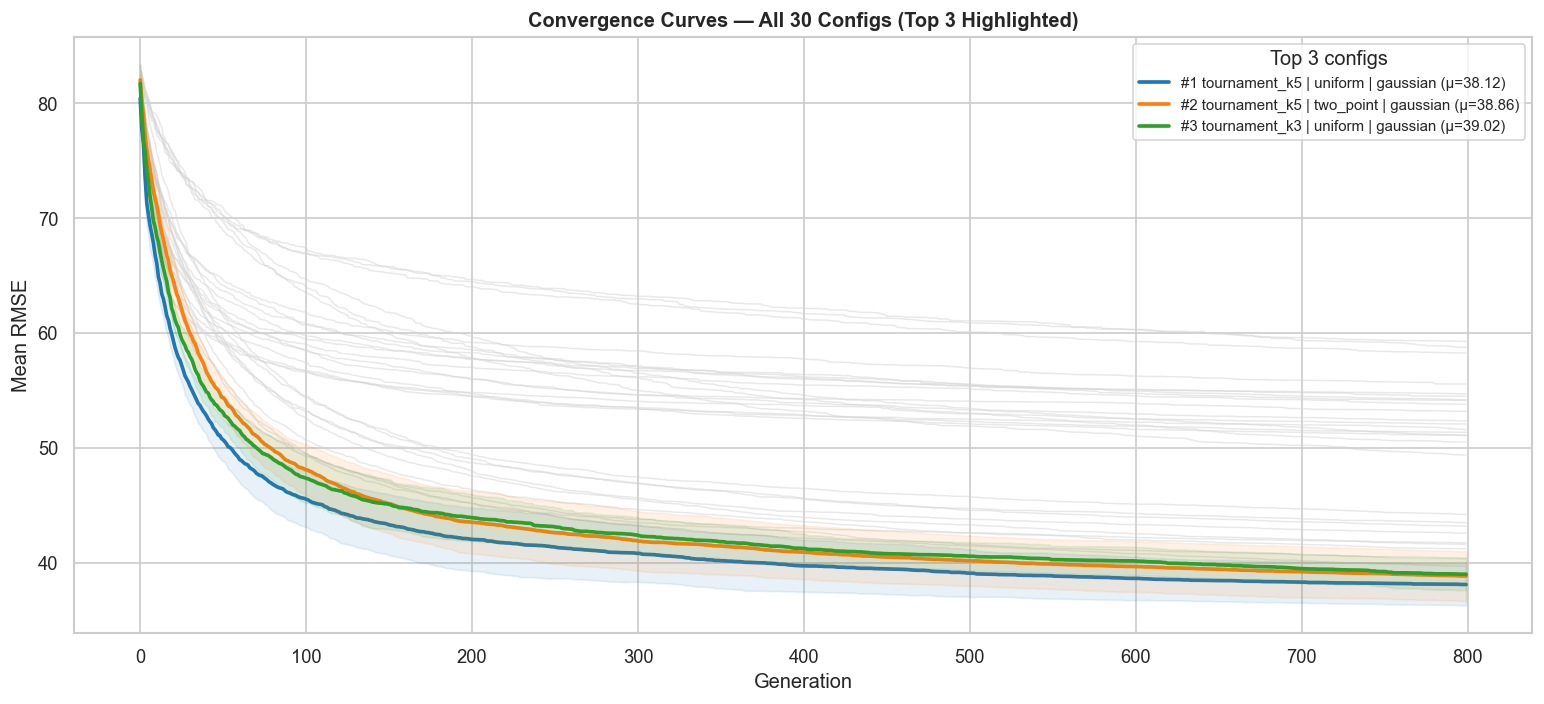

In [3]:
top3_ids = summary.head(3)['config_id'].tolist()
palette3  = sns.color_palette('tab10', 3)

fig, ax = plt.subplots(figsize=(13, 6))

for cid, group in df.groupby('config_id'):
    curves = np.array(group['fitness_curve'].tolist())
    ax.plot(curves.mean(axis=0), color='lightgray', alpha=0.5, linewidth=0.9, zorder=1)

for i, cid in enumerate(top3_ids):
    group  = df[df['config_id'] == cid]
    curves = np.array(group['fitness_curve'].tolist())
    mean_c = curves.mean(axis=0)
    std_c  = curves.std(axis=0)
    r      = summary[summary['config_id'] == cid].iloc[0]
    label  = f"#{i+1} {r['selection']} | {r['crossover']} | {r['mutation']} (μ={r['rmse_mean']:.2f})"
    ax.plot(mean_c, color=palette3[i], linewidth=2.2, label=label, zorder=2)
    ax.fill_between(range(len(mean_c)), mean_c - std_c, mean_c + std_c,
                    color=palette3[i], alpha=0.1, zorder=2)

ax.set_xlabel('Generation')
ax.set_ylabel('Mean RMSE')
ax.set_title('Convergence Curves — All 30 Configs (Top 3 Highlighted)', fontweight='bold')
ax.legend(fontsize=9, title='Top 3 configs', loc='upper right')
plt.tight_layout()
plt.show()

#### Best single result: visual comparison with the target

The single best run across all 300 experiments, side by side with Vermeer's original. This gives an intuitive feel for how much the grid search's winner actually approximates the painting.

Best config : sel_tournament_k5__xo_uniform__mut_gaussian
Best RMSE   : 34.4096
Run         : 4


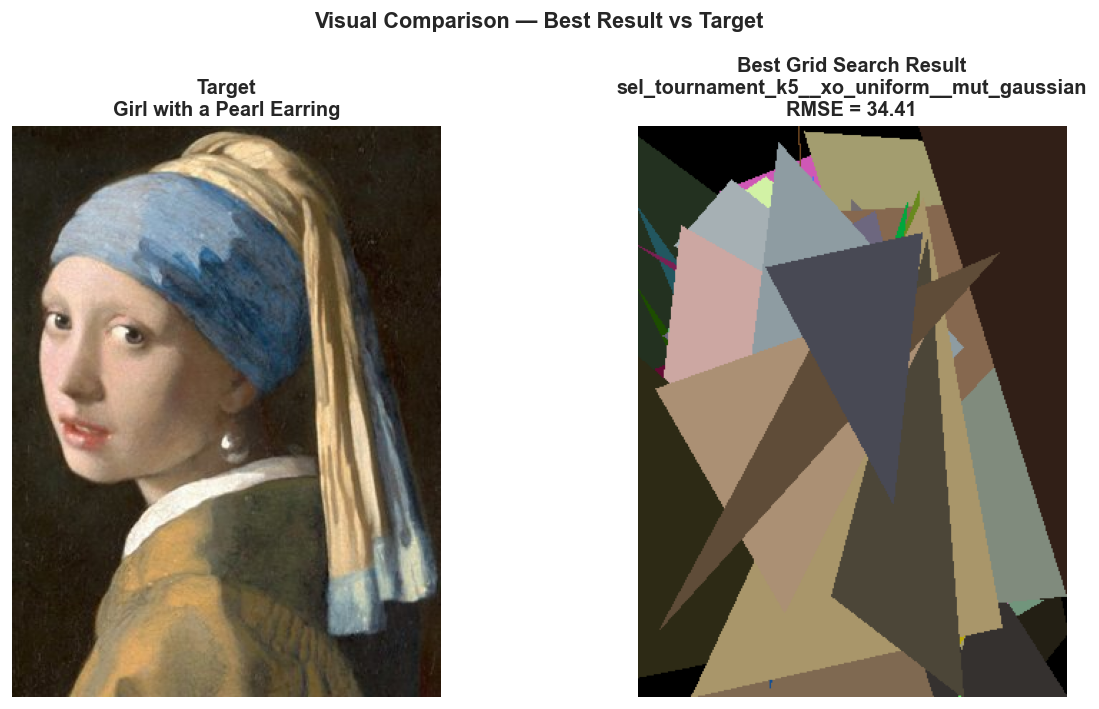

In [4]:
best_row = df.loc[df['rmse_final'].idxmin()]
cid      = best_row['config_id']
run_num  = int(best_row['run'])
print(f'Best config : {cid}')
print(f'Best RMSE   : {best_row["rmse_final"]:.4f}')
print(f'Run         : {run_num}')

target   = Image.open('data/girl_pearl_earring.png')
img_path = IMG_DIR / f'{cid}_run{run_num}.png'
best_img = Image.open(img_path)

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
axes[0].imshow(target)
axes[0].set_title('Target\nGirl with a Pearl Earring', fontweight='bold')
axes[0].axis('off')
axes[1].imshow(best_img)
axes[1].set_title(f'Best Grid Search Result\n{cid}\nRMSE = {best_row["rmse_final"]:.2f}', fontweight='bold')
axes[1].axis('off')
plt.suptitle('Visual Comparison — Best Result vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Conclusions

The top-5 configurations all use **gaussian mutation**, the only operator that is consistent across every top result. Random reset does not appear once in the top rankings.

**Tournament selection** is the clear winner for selection: all top-5 configs use it, and performance improves monotonically with k (k5 > k3 > k2). Roulette and rank selection never reach the top positions.

**Crossover type has a weaker effect.** The #1 config uses uniform, but #2 uses two-point and #4 uses one-point, all three variants appear in the top-5 with very similar means. Crossover choice matters less than selection and mutation.

The best single run (RMSE = 34.41) comes from **tournament\_k5 + uniform + gaussian**, which also has the best mean (38.12).

The grid search identifies mutation as the dominant factor and crossover as the weakest a hypothesis we quantify in Section 2.2.

---

## 2.2 Operators Contribution Analysis (Challenge 3)

To isolate the contribution of one operator, we **marginalise** over the other two, pooling all runs that share the same operator variant regardless of the other factors, this gives:

| Operator | Levels | Runs per level |
|---|---|---|
| Mutation | 2 | 150 |
| Selection | 5 | 60 |
| Crossover | 3 | 100 |

All well above K ≥ 30, the threshold for statistical reliability. Error bars in the plots below represent ± 1 standard deviation; **non-overlapping bands indicate a statistically significant difference**.

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

LOGS_DIR = Path("results/standard_grid/logs")
OUT_DIR  = Path("results/standard_grid")

print(f"LOGS_DIR absolute: {LOGS_DIR.absolute()}")
print(f"LOGS_DIR exists:   {LOGS_DIR.exists()}")
files = sorted(LOGS_DIR.glob("*.json"))
print(f"JSON files found:  {len(files)}")

records = []
for fpath in files:
    d     = json.loads(fpath.read_text(encoding="utf-8"))
    parts = d["config_id"].split("__")
    records.append({
        "selection":     parts[0].replace("sel_", ""),
        "crossover":     parts[1].replace("xo_",  ""),
        "mutation":      parts[2].replace("mut_", ""),
        "rmse_final":    float(d["rmse_final"]),
        "fitness_curve": d["fitness_curve"],
    })

df = pd.DataFrame(records)

SEL_ORDER = ["roulette", "rank", "tournament_k2", "tournament_k3", "tournament_k5"]
XO_ORDER  = ["one_point", "two_point", "uniform"]
MUT_ORDER = ["random_reset", "gaussian"]

print(f"Loaded {len(df)} runs across {df[['selection','crossover','mutation']].drop_duplicates().shape[0]} configurations.")

LOGS_DIR absolute: c:\Users\giosu\Desktop\cifo_project\clean_project_test\results\standard_grid\logs
LOGS_DIR exists:   True
JSON files found:  300
Loaded 300 runs across 30 configurations.


#### 2.2.1 Marginal Effect of Each Operator

Each bar shows the **mean final RMSE averaged across all combinations of the other two operators**, with ± 1 std error bars. A larger spread between bars means that operator has a stronger influence on the result.

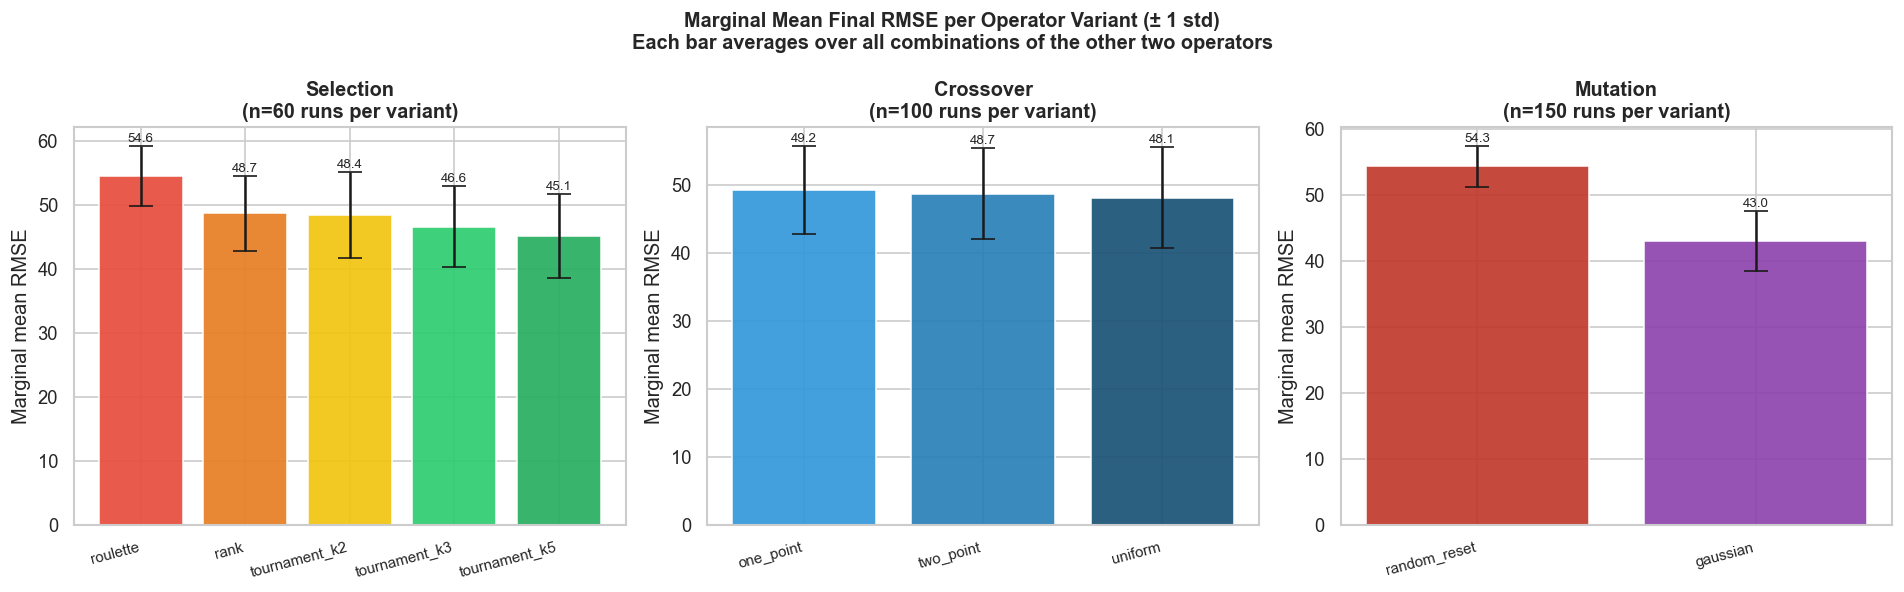

In [6]:
SEL_COLORS = {
    "roulette":      "#e74c3c",
    "rank":          "#e67e22",
    "tournament_k2": "#f1c40f",
    "tournament_k3": "#2ecc71",
    "tournament_k5": "#27ae60",
}
XO_COLORS  = {"one_point": "#3498db", "two_point": "#2980b9", "uniform": "#1a5276"}
MUT_COLORS = {"random_reset": "#c0392b", "gaussian": "#8e44ad"}

def marginal_stats(df, col, order):
    return df.groupby(col)["rmse_final"].agg(mean="mean", std="std").reindex(order)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def bar_panel(ax, stats_df, order, colors, title, n_per_level):
    for i, v in enumerate(order):
        row = stats_df.loc[v]
        ax.bar(i, row["mean"], yerr=row["std"], color=colors[v],
               capsize=7, edgecolor="white", alpha=0.92)
        ax.text(i, row["mean"] + row["std"] + 0.2,
                f"{row['mean']:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Marginal mean RMSE")
    ax.set_title(f"{title}\n(n={n_per_level} runs per variant)", fontweight="bold")

bar_panel(axes[0], marginal_stats(df, "selection", SEL_ORDER), SEL_ORDER, SEL_COLORS, "Selection", 60)
bar_panel(axes[1], marginal_stats(df, "crossover",  XO_ORDER),  XO_ORDER,  XO_COLORS,  "Crossover", 100)
bar_panel(axes[2], marginal_stats(df, "mutation",   MUT_ORDER), MUT_ORDER, MUT_COLORS, "Mutation",  150)

plt.suptitle(
    "Marginal Mean Final RMSE per Operator Variant (± 1 std)\n"
    "Each bar averages over all combinations of the other two operators",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "contribution_marginal_bars.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2.2.2 Convergence Curves by Operator

Mean fitness curve per variant (± 1 std band), averaged across all runs sharing that variant. This shows not only the final RMSE but **how quickly and stably** each variant converges over 800 generations.

Non-overlapping bands at the end of the curve confirm that the differences observed above are consistent throughout the optimisation process.

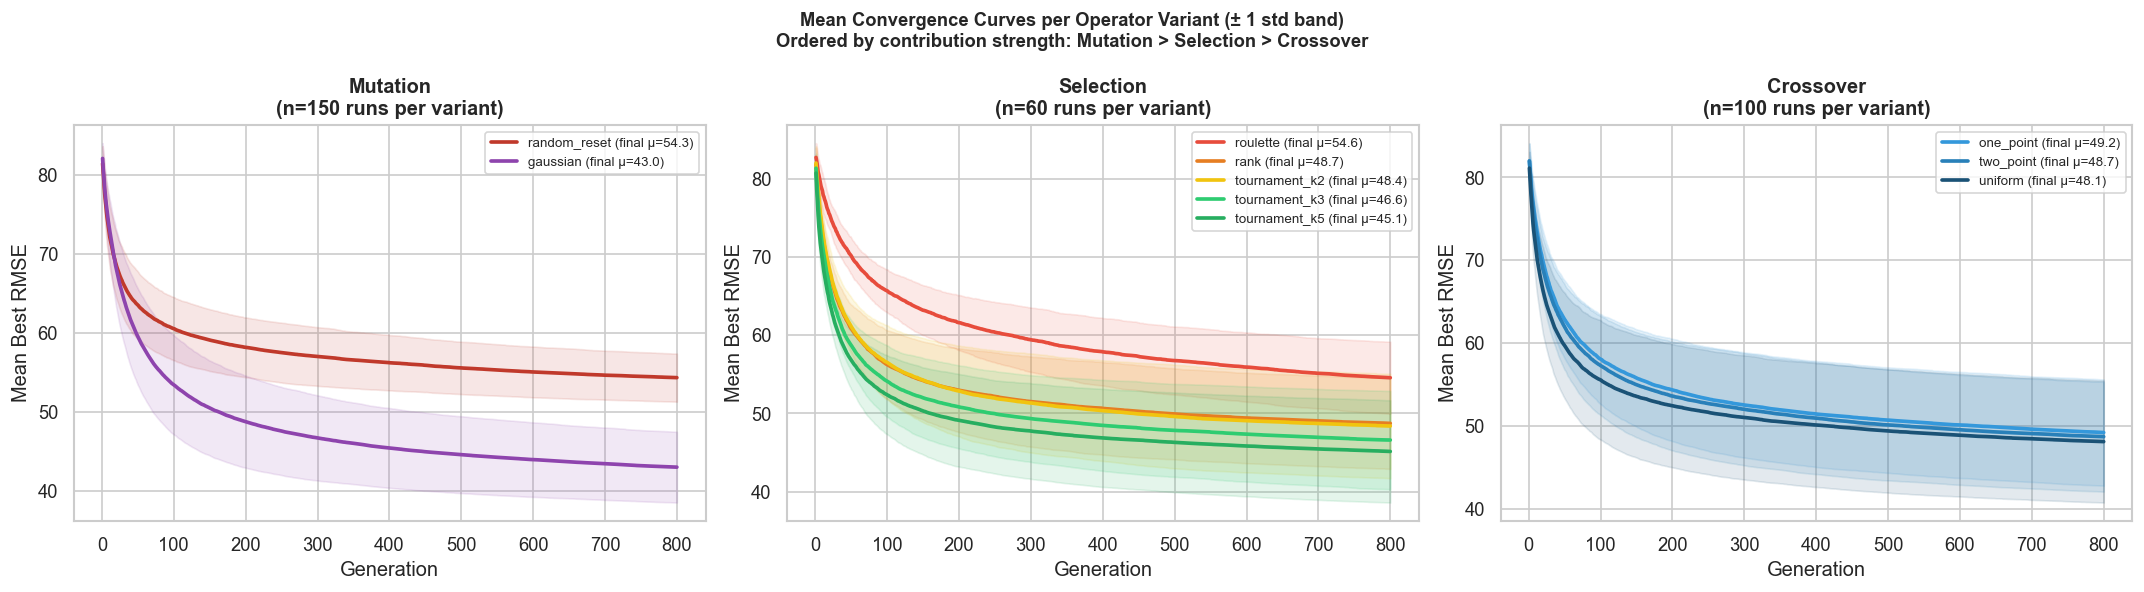

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def convergence_panel(ax, df, col, order, colors, title):
    for variant in order:
        group  = df[df[col] == variant]
        curves = np.array(group["fitness_curve"].tolist())
        mean_c = curves.mean(axis=0)
        std_c  = curves.std(axis=0)
        gens   = np.arange(1, len(mean_c) + 1)
        ax.plot(gens, mean_c, color=colors[variant], linewidth=2.2,
                label=f"{variant} (final μ={mean_c[-1]:.1f})")
        ax.fill_between(gens, mean_c - std_c, mean_c + std_c,
                        color=colors[variant], alpha=0.12)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Mean Best RMSE")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)

convergence_panel(axes[0], df, "mutation",   MUT_ORDER, MUT_COLORS,
                  "Mutation\n(n=150 runs per variant)")
convergence_panel(axes[1], df, "selection",  SEL_ORDER, SEL_COLORS,
                  "Selection\n(n=60 runs per variant)")
convergence_panel(axes[2], df, "crossover",  XO_ORDER,  XO_COLORS,
                  "Crossover\n(n=100 runs per variant)")

plt.suptitle(
    "Mean Convergence Curves per Operator Variant (± 1 std band)\n"
    "Ordered by contribution strength: Mutation > Selection > Crossover",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "contribution_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2.2.3 Conclusion

Across 300 independent runs, the three operators contribute very differently to the final RMSE:

**Mutation** is the dominant factor. The gap between `random_reset` and `gaussian` is large, with non-overlapping error bars throughout the entire convergence, switching mutation type produces a substantial and consistent change in result quality.

**Selection** has a moderate but meaningful impact. Tournament-based methods (especially higher k) consistently outperform roulette and rank selection. The spread across variants is visible both in the bar chart and in the convergence curves.

**Crossover** has minimal influence. The three methods (`one_point`, `two_point`, `uniform`) produce nearly identical marginal means with heavily overlapping error bars, the choice of crossover operator is largely irrelevant for this problem.

---

# 3. Statistical Validation of the Best Configuration

The top 3 operator configurations from the grid search are re-run **30 independent times each**, the minimum K required for statistical reliability, to verify that the ranking observed in Section 2 holds under repeated sampling.

| # | Selection | Crossover | Mutation |
|---|---|---|---|
| 1 | Tournament k=5 | Uniform | Gaussian |
| 2 | Tournament k=5 | Two-point | Gaussian |
| 3 | Tournament k=3 | Uniform | Gaussian |

**Fixed hyperparameters:** `pop=100`, `gen=800`, `xo_prob=0.7`, `mut_prob=0.05`, `elitesize=2`

| Test | Purpose |
|------|---------|
| Kruskal-Wallis | Is there any overall difference among the three? (non-parametric ANOVA) |
| Mann-Whitney U + Bonferroni | Which specific pairs differ? Corrected threshold: α = 0.05 / 3 = 0.0167 |

Non-parametric tests are used because GA fitness distributions are not guaranteed to be Gaussian, the Bonferroni correction divides the significance threshold α by the number of pairwise comparisons to control the probability of obtaining at least one false positive when multiple hypothesis tests are performed simultaneously.

> **[`run_validation.py`](experiments/run_validation.py)**  
*Re-runs the top 3 operator configurations 30 times each.*

---

## 3.1 Results Analysis

#### Loading Data

In [8]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats
from PIL import Image

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

BASE_DIR = Path("results/validation")
DATA_DIR = Path("data")

CONFIGS = [
    {"id": "tournament_k5__uniform__gaussian",   "label": "k5 | uniform | gaussian",   "color": "#2e5fa3"},
    {"id": "tournament_k5__two_point__gaussian", "label": "k5 | two-point | gaussian", "color": "#e67e22"},
    {"id": "tournament_k3__uniform__gaussian",   "label": "k3 | uniform | gaussian",   "color": "#27ae60"},
]
CONFIG_IDS    = [c["id"]    for c in CONFIGS]
CONFIG_LABELS = {c["id"]: c["label"] for c in CONFIGS}
CONFIG_COLORS = {c["id"]: c["color"] for c in CONFIGS}
ALPHA_CORRECTED = 0.05 / 3  # Bonferroni: 3 pairwise comparisons

records = []
for cfg in CONFIGS:
    logs_dir = BASE_DIR / cfg["id"] / "logs"
    for fpath in sorted(logs_dir.glob("*.json")):
        d = json.loads(fpath.read_text(encoding="utf-8"))
        records.append({
            "config_id":     d["config_id"],
            "label":         cfg["label"],
            "run":           int(d["run"]),
            "rmse_final":    float(d["rmse_final"]),
            "fitness_curve": d["fitness_curve"],
            "image_path":    d.get("image_path", ""),
        })

df = pd.DataFrame(records)
summary = (
    df.groupby("config_id")
    .agg(
        n          =("rmse_final", "count"),
        rmse_mean  =("rmse_final", "mean"),
        rmse_std   =("rmse_final", "std"),
        rmse_min   =("rmse_final", "min"),
        rmse_max   =("rmse_final", "max"),
        rmse_median=("rmse_final", "median"),
    )
    .reindex(CONFIG_IDS)
    .round(4)
)
print(f"Loaded {len(df)} runs across {df['config_id'].nunique()} configurations")
summary

Loaded 90 runs across 3 configurations


,n,rmse_mean,rmse_std,rmse_min,rmse_max,rmse_median
config_id,,,,,,
tournament_k5__uniform__gaussian,30,37.5358,2.0494,33.2037,42.2770,37.5477
tournament_k5__two_point__gaussian,30,38.9577,1.9224,34.8665,43.7008,38.7908
tournament_k3__uniform__gaussian,30,38.7311,2.1527,35.2009,42.5758,38.4450


#### RMSE Distribution — Box Plot

Each box shows the distribution of final RMSE across the 30 runs, the dots are individual runs, their spread tells us how **consistent** each configuration is.

A good configuration has a **low median** (performs well on average) and a **narrow box** (reliable across runs).

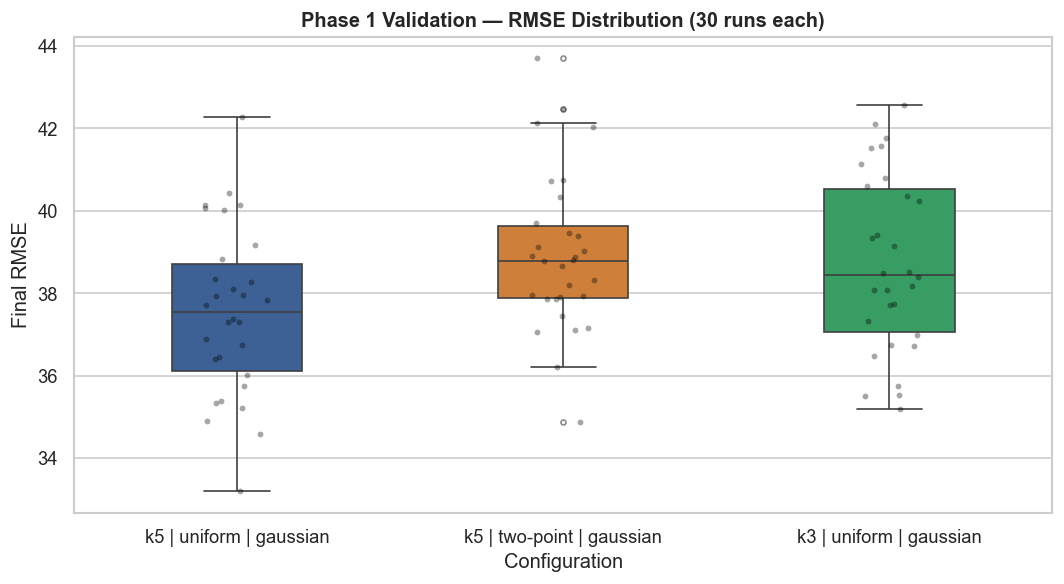

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df, x="config_id", y="rmse_final",
    order=CONFIG_IDS,
    hue="config_id", hue_order=CONFIG_IDS,
    palette=CONFIG_COLORS,
    legend=False, width=0.4,
    flierprops={"marker": ".", "alpha": 0.6},
    ax=ax,
)
sns.stripplot(
    data=df, x="config_id", y="rmse_final",
    order=CONFIG_IDS,
    color="black", alpha=0.35, size=3.5, jitter=True, ax=ax,
)

ax.set_xticks(range(len(CONFIG_IDS)))
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIG_IDS], fontsize=11)
ax.set_xlabel("Configuration")
ax.set_ylabel("Final RMSE")
ax.set_title("Phase 1 Validation — RMSE Distribution (30 runs each)", fontweight="bold")
plt.tight_layout()
plt.savefig("results/validation/boxplot_validation.png", dpi=150, bbox_inches="tight")
plt.show()

#### Convergence Curves

Each line shows the **mean best RMSE at each generation**, averaged across 30 runs, the shaded band is ± 1 standard deviation.

A curve that drops fast indicates quick convergence; a narrow band means consistent behaviour across runs. Non-overlapping bands at the end suggest the final difference is statistically meaningful.

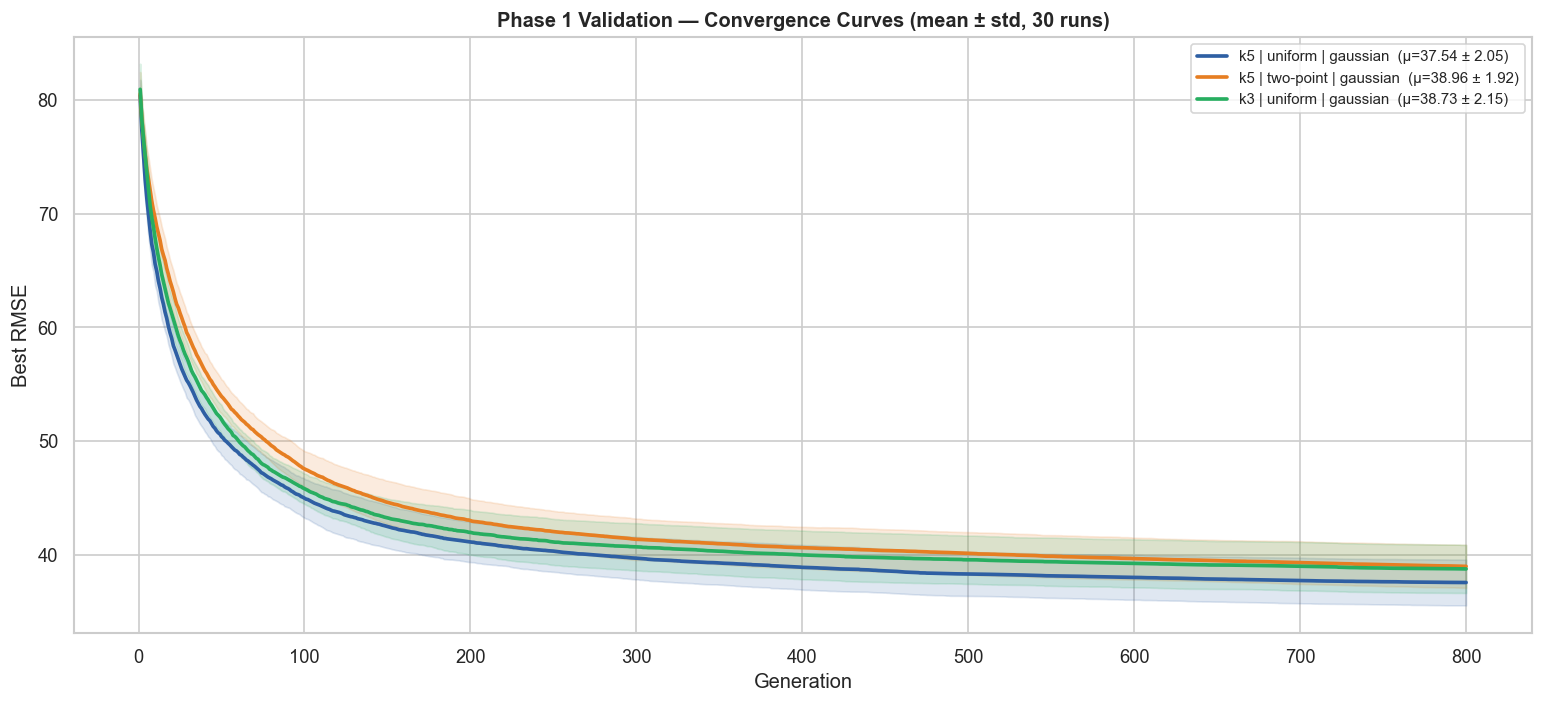

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))

for cfg_id in CONFIG_IDS:
    group  = df[df["config_id"] == cfg_id]
    curves = np.array(group["fitness_curve"].tolist())
    mean_c = curves.mean(axis=0)
    std_c  = curves.std(axis=0)
    gens   = np.arange(1, len(mean_c) + 1)
    row    = summary.loc[cfg_id]
    ax.plot(gens, mean_c,
            color=CONFIG_COLORS[cfg_id], linewidth=2.2,
            label=f"{CONFIG_LABELS[cfg_id]}  (μ={row['rmse_mean']:.2f} ± {row['rmse_std']:.2f})")
    ax.fill_between(gens, mean_c - std_c, mean_c + std_c,
                    color=CONFIG_COLORS[cfg_id], alpha=0.15)

ax.set_xlabel("Generation")
ax.set_ylabel("Best RMSE")
ax.set_title("Phase 1 Validation — Convergence Curves (mean ± std, 30 runs)", fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("results/validation/convergence_validation.png", dpi=150, bbox_inches="tight")
plt.show()

#### Statistical Tests

The plots above give a visual impression, the tests below make it formally verifiable.

**Why non-parametric tests?** GA results are stochastic and not guaranteed to follow a normal distribution.

**Step 1 — Kruskal-Wallis (omnibus):** checks whether the three configurations come from the same population. H₀: all three have the same median RMSE. If p < 0.05, pairwise comparisons are justified.

**Step 2 — Pairwise Mann-Whitney U:** compares each pair directly. The **Bonferroni correction** tightens the threshold to α = 0.05 / 3 = **0.0167** to control for multiple comparisons.

In [11]:
rmse_by_cfg = {
    cfg_id: df[df["config_id"] == cfg_id]["rmse_final"].values
    for cfg_id in CONFIG_IDS
}

# ── Kruskal-Wallis (omnibus) ───────────────────────────────────────────────────
h_stat, kw_p = stats.kruskal(*rmse_by_cfg.values())
print(f"Kruskal-Wallis:  H = {h_stat:.4f},  p = {kw_p:.4f}")
if kw_p < 0.05:
    print("→ At least one configuration differs significantly (p < 0.05). Pairwise comparisons are justified.")
else:
    print("→ No significant overall difference found (p ≥ 0.05). Pairwise comparisons are not warranted.")

print()

# ── Pairwise Mann-Whitney U (Bonferroni-corrected) ────────────────────────────
pairs = [
    (CONFIG_IDS[0], CONFIG_IDS[1]),
    (CONFIG_IDS[0], CONFIG_IDS[2]),
    (CONFIG_IDS[1], CONFIG_IDS[2]),
]

rows = []
for a_id, b_id in pairs:
    a, b       = rmse_by_cfg[a_id], rmse_by_cfg[b_id]
    stat_val, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    sig        = "YES" if p < ALPHA_CORRECTED else "no"
    winner     = CONFIG_LABELS[a_id] if a.mean() < b.mean() else CONFIG_LABELS[b_id]
    rows.append({
        "A":           CONFIG_LABELS[a_id],
        "B":           CONFIG_LABELS[b_id],
        "mean A":      round(a.mean(), 4),
        "mean B":      round(b.mean(), 4),
        "p-value":     round(p, 4),
        "significant": sig,
        "better":      winner if sig == "YES" else "—",
    })

results_df = pd.DataFrame(rows)
print(f"Bonferroni-corrected threshold: p < {ALPHA_CORRECTED:.4f}\n")
display(results_df)

Kruskal-Wallis:  H = 7.5221,  p = 0.0233
→ At least one configuration differs significantly (p < 0.05). Pairwise comparisons are justified.

Bonferroni-corrected threshold: p < 0.0167



,A,B,mean A,mean B,p-value,significant,better
0,k5 | uniform | gaussian,k5 | two-point | gaussian,37.5359,38.9577,0.0108,YES,k5 | uniform | gaussian
1,k5 | uniform | gaussian,k3 | uniform | gaussian,37.5359,38.7311,0.0351,no,—
2,k5 | two-point | gaussian,k3 | uniform | gaussian,38.9577,38.7311,0.6520,no,—


### Conclusions

The validation phase confirms the ranking observed in the grid search. `tournament_k5__uniform__gaussian` achieves the lowest mean RMSE across 30 runs. The Kruskal-Wallis test detects an overall difference among the three configurations (p < 0.05); however, pairwise Mann-Whitney reveals that only one pair is statistically significant: `k5 | uniform | gaussian` vs `k5 | two-point | gaussian` (p = 0.0108). The remaining two comparisons do not reach significance, meaning configurations 2 and 3 cannot be confidently separated from each other.

`tournament_k5__uniform__gaussian` is nonetheless selected as the best configuration and carried forward as the fixed baseline for probability tuning in Section 5.

---

# 4. Different Representation and Initialization Experiments

Before tuning crossover and mutation probabilities, we tested two alternative approaches aimed at reducing the starting RMSE, the hypothesis being that a better initial state could lead to stronger final solutions regardless of operator choice.

- **Alpha (4.1):** 10-gene triangles (adds alpha channel A). Custom RGBA renderer and alpha-aware mutation.
- **Coverage (4.2):** 10×10 grid placement at initialization. Operators and GA loop unchanged.
- **Results Analysis (4.3):** Comparative analysis of baseline, alpha, and coverage across RMSE distribution, convergence curves, and best visual output.

---

## 4.1 Alpha Transparency Factor

Genome: `[x1,y1,x2,y2,x3,y3,R,G,B,A]` per triangle, 1000 genes total.

> **[`triangle_solution_alpha.py`](core/triangle_solution_alpha.py)**  
*Extends the base solution with a 10-gene triangle representation, adding an alpha channel A ∈ [50, 220] to each triangle, and computes fitness by comparing the RGBA-rendered image against the target.*

> **[`render_alpha.py`](core/render_alpha.py)**  
*Renders a list of RGBA triangles onto a transparent canvas using PIL's `alpha_composite`, producing a blended approximation that accounts for triangle transparency.*

> **[`mutation_alpha.py`](core/mutation_alpha.py)**  
*Applies Gaussian noise to all 10 genes of each selected triangle, including the alpha channel, keeping values within their valid ranges after perturbation.*

> **[`run_alpha.py`](experiments/run_alpha.py)**  
*Runs 10 independent GA trials with the alpha-extended solution.*

| Aspect | Standard | Alpha |
|--------|----------|-------|
| Genes/triangle | 9 | 10 |
| Renderer | RGB | RGBA composite |
| Mutation | `gaussian_mutation` | `gaussian_mutation_alpha` |
| Crossover/Selection | Unchanged | Unchanged |

---

## 4.2 Coverage Initialization

Canvas divided into a 10×10 grid, one triangle placed per cell at initialization.

> **[`triangle_solution_coverage.py`](core/triangle_solution_coverage.py)**  
*Overrides the default random initialisation to place one triangle per cell of a 10×10 grid, ensuring full canvas coverage from generation 0, the fitness function, operators, and GA loop remain unchanged.*

> **[`run_coverage.py`](experiments/run_coverage.py)**  
*Runs 10 independent GA trials with the coverage-initialised solution.*

Only `random_initial_representation()` changes vs Section 1, operators and GA loop are identical.

---

## 4.3 Results Analysis

This section compares the three representation variants under the same fixed GA configuration (best config from Section 3: `tournament_k5__uniform__gaussian`).

| Representation | Description |
|---|---|
| `baseline` | Standard random initialisation |
| `alpha` | Triangles with a learnable alpha channel |
| `coverage` | Coverage-based initialisation |

**Fixed hyperparameters:** pop=80, gen=800, xo_prob=0.7, mut_prob=0.05, elitesize=2

> **Note on statistical validity:** 10 independent runs are not enough for formal statistical testing, the higher compute cost of the `alpha` representation made running 30 trials impractical with our resources, so results should be interpreted as **directional evidence**, not definitive conclusions.

#### Loading Data

In [12]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SOURCES = {
    "baseline": {
        "logs":    Path("results/standard_grid/logs"),
        "images":  Path("results/standard_grid/images"),
        "pattern": "*tournament_k5*uniform*gaussian_run*.json",
    },
    "alpha": {
        "logs":    Path("results/alpha/logs"),
        "images":  Path("results/alpha/images"),
        "pattern": "*.json",
    },
    "coverage": {
        "logs":    Path("results/coverage/logs"),
        "images":  Path("results/coverage/images"),
        "pattern": "*.json",
    },
}

REP_ORDER  = ["baseline", "alpha", "coverage"]
REP_COLORS = {"baseline": "#7f8c8d", "alpha": "#2980b9", "coverage": "#27ae60"}

records_rep = []
for rep, cfg in SOURCES.items():
    for fpath in sorted(cfg["logs"].glob(cfg["pattern"])):
        d = json.loads(fpath.read_text(encoding="utf-8"))
        records_rep.append({
            "representation": rep,
            "config_id":      d.get("config_id", ""),
            "run":            int(d["run"]),
            "rmse_final":     float(d["rmse_final"]),
            "fitness_curve":  d["fitness_curve"],
            "images_dir":     cfg["images"],
        })

df_rep = pd.DataFrame(records_rep)
summary_rep = (
    df_rep.groupby("representation")
    .agg(
        n          =("rmse_final", "count"),
        rmse_mean  =("rmse_final", "mean"),
        rmse_std   =("rmse_final", "std"),
        rmse_min   =("rmse_final", "min"),
        rmse_max   =("rmse_final", "max"),
        rmse_median=("rmse_final", "median"),
    )
    .reindex(REP_ORDER)
    .round(4)
)
print(f"Loaded {len(df_rep)} runs across {df_rep['representation'].nunique()} representations")
summary_rep

Loaded 30 runs across 3 representations


,n,rmse_mean,rmse_std,rmse_min,rmse_max,rmse_median
representation,,,,,,
baseline,10,38.1214,1.9169,34.4096,41.1856,37.9512
alpha,10,36.5064,1.0097,34.3736,37.9729,36.7472
coverage,10,42.0998,0.9132,40.3339,43.8150,42.0620


#### RMSE Distribution — Box Plot

Each box shows the spread of final RMSE across the 10 runs of that representation, individual dots are single runs, their spread captures how **consistent** each representation is across different random seeds.

A good representation has a **low median** and a **narrow box**.

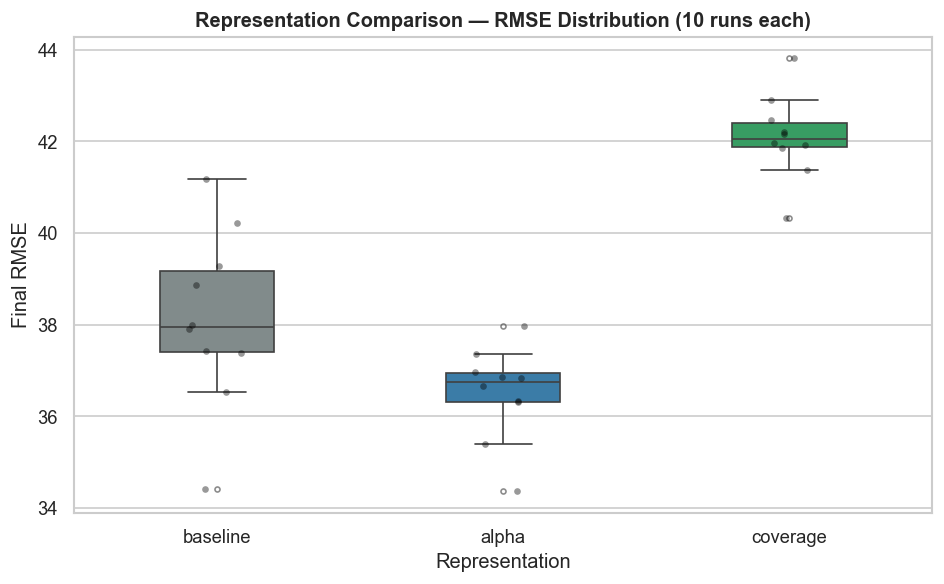

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_rep, x="representation", y="rmse_final",
    order=REP_ORDER,
    hue="representation", hue_order=REP_ORDER,
    palette=REP_COLORS,
    legend=False, width=0.4,
    flierprops={"marker": ".", "alpha": 0.6},
    ax=ax,
)
sns.stripplot(
    data=df_rep, x="representation", y="rmse_final",
    order=REP_ORDER,
    color="black", alpha=0.4, size=4, jitter=True, ax=ax,
)

ax.set_xlabel("Representation")
ax.set_ylabel("Final RMSE")
ax.set_title("Representation Comparison — RMSE Distribution (10 runs each)", fontweight="bold")
plt.tight_layout()
plt.savefig("results/representation_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

#### Convergence Curves

Each line shows the **mean best RMSE at each generation**, averaged across 10 runs, the shaded band is ± 1 standard deviation.

Beyond the final value, this plot reveals **how** each representation reaches its result: how fast it drops, whether it plateaus early, and how stable it is throughout the search.

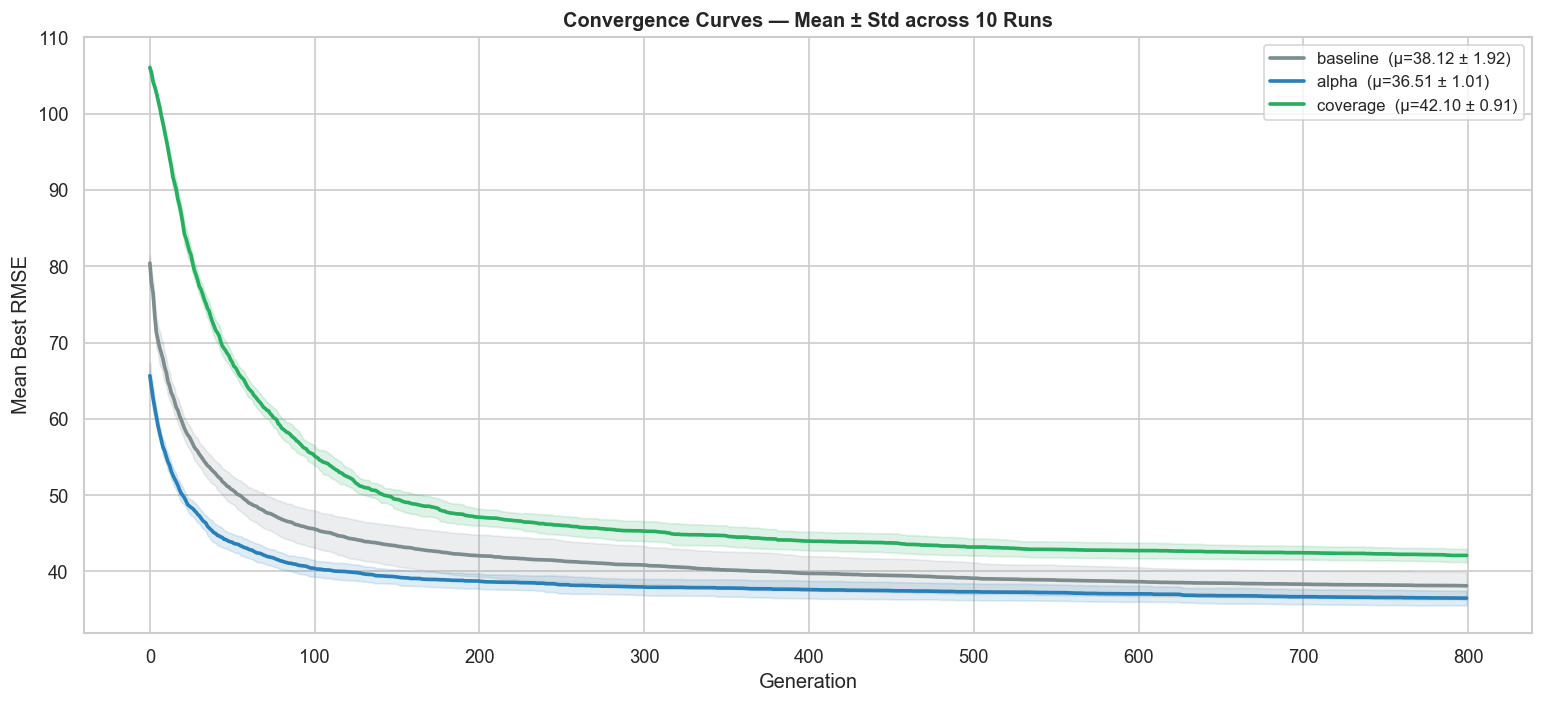

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))

for rep in REP_ORDER:
    group  = df_rep[df_rep["representation"] == rep]
    curves = np.array(group["fitness_curve"].tolist())
    mean_c = curves.mean(axis=0)
    std_c  = curves.std(axis=0)
    gens   = np.arange(len(mean_c))
    row    = summary_rep.loc[rep]
    ax.plot(gens, mean_c,
            color=REP_COLORS[rep], linewidth=2.2,
            label=f"{rep}  (μ={row['rmse_mean']:.2f} ± {row['rmse_std']:.2f})")
    ax.fill_between(gens, mean_c - std_c, mean_c + std_c,
                    color=REP_COLORS[rep], alpha=0.15)

ax.set_xlabel("Generation")
ax.set_ylabel("Mean Best RMSE")
ax.set_title("Convergence Curves — Mean ± Std across 10 Runs", fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("results/representation_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

#### Visual Comparison — Best Result per Representation

The best image produced by each representation (the run with the lowest final RMSE), shown alongside the original target.

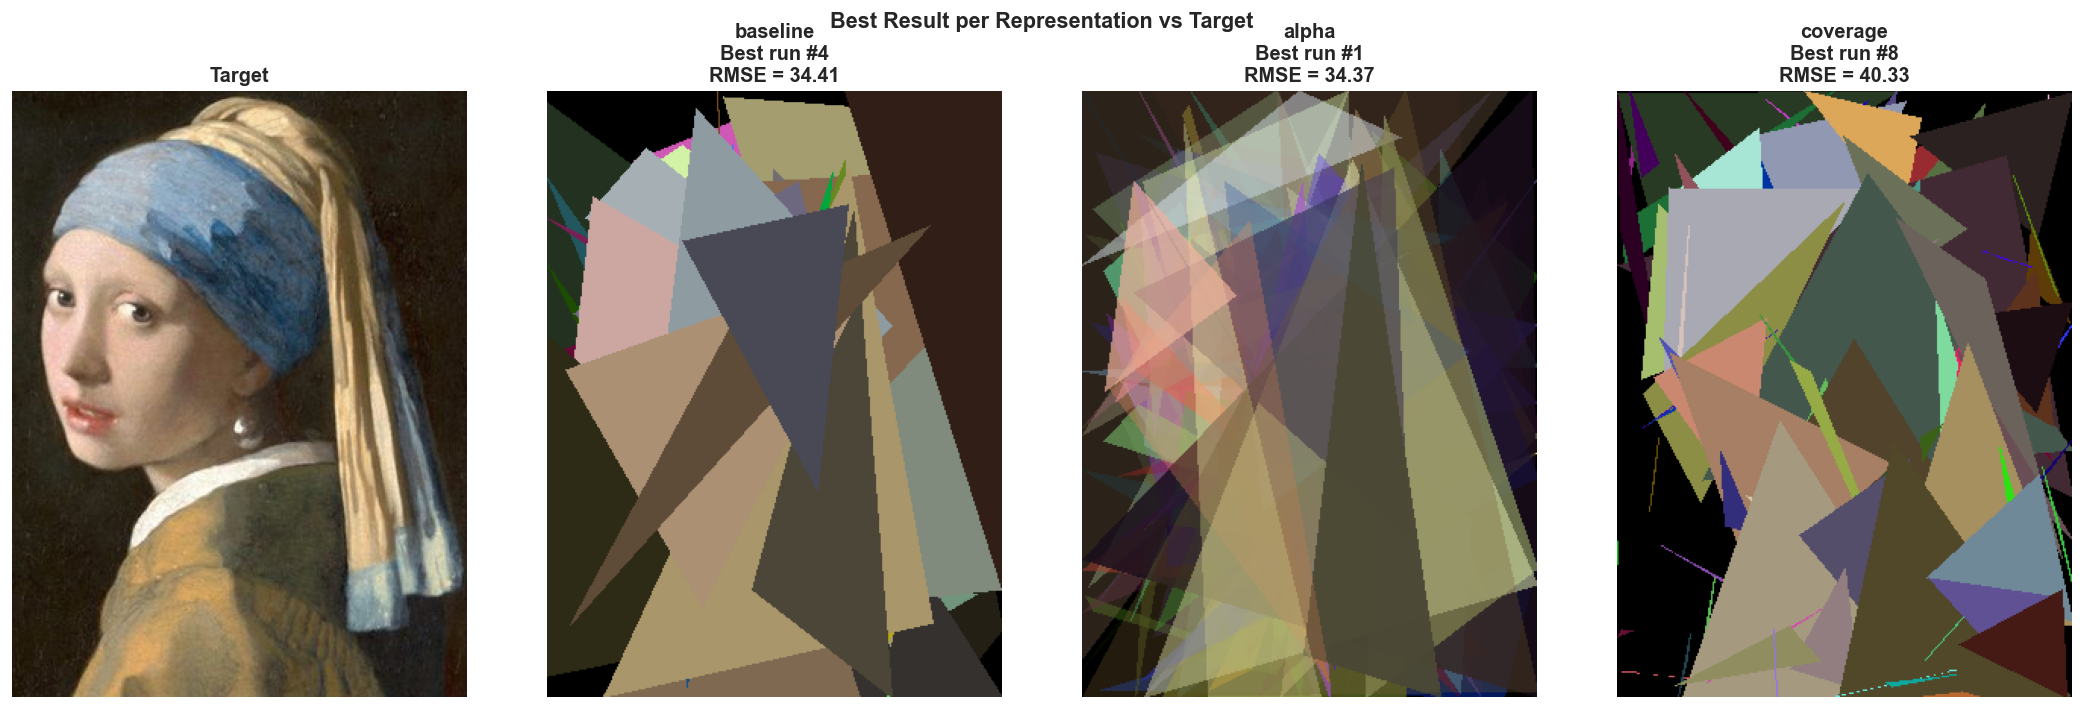

In [15]:
target = Image.open("data/girl_pearl_earring.png")

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes[0].imshow(target)
axes[0].set_title("Target", fontweight="bold")
axes[0].axis("off")

for ax, rep in zip(axes[1:], REP_ORDER):
    rep_df   = df_rep[df_rep["representation"] == rep]
    best_row = rep_df.loc[rep_df["rmse_final"].idxmin()]
    img_dir  = best_row["images_dir"]
    run      = int(best_row["run"])
    # baseline: {config_id}_run{N}.png  |  alpha/coverage: run{N}.png
    if rep == "baseline":
        img_file = f"{best_row['config_id']}_run{run}.png"
    else:
        img_file = f"run{run}.png"
    try:
        ax.imshow(Image.open(img_dir / img_file))
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"not found:\n{img_file}", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
    ax.set_title(
        f"{rep}\nBest run #{run}\nRMSE = {best_row['rmse_final']:.2f}",
        fontweight="bold",
    )
    ax.axis("off")

plt.suptitle("Best Result per Representation vs Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/representation_best_results.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusions

**Alpha — promising directional result**

The `alpha` representation achieves the lowest mean RMSE (36.51 vs 38.12 for baseline), with a narrower distribution across runs (std 1.01 vs 1.92). The learnable alpha channel allows triangles to be semi-transparent, enabling gradient blending rather than hard opaque coverage, this gives the GA a richer search space that converges more consistently across random seeds.

Given the exploratory nature of this comparison (10 runs, no formal statistical test), this result is treated as a **promising signal**. A full 30-run validation would be required to draw a definitive conclusion.

**Coverage — conclusively ruled out**

Coverage-based initialisation consistently underperforms both alternatives, with a mean RMSE of 42.10. Forcing triangles to spatially cover the image at initialisation over-constrains the search, limiting early exploration and trapping the GA in a suboptimal region of the fitness landscape. Despite having the lowest inter-run variance (std 0.91), it converges reliably to *poor* solutions. Coverage is eliminated from further consideration.


| Representation | Mean RMSE | Std | 
|---|---|---|
| **alpha** | **36.51** | **1.01** | 
| baseline | 38.12 | 1.92 |
| coverage | 42.10 | 0.91 |

---

# 5. Probability Tuning (Crossover and Mutation)

In this section we explore the tuning of the two operator probabilities (`xo_prob`, `mut_prob`) using the best operator configuration from Section 3. The grid is grounded in the **Schema Theorem** and the **Building Blocks Hypothesis (BBH)**.

**Fixed config:** tournament k=5 | uniform crossover | gaussian mutation | pop=100, gen=800, elitesize=2

**`xo_prob` ∈ {0.7, 0.9}**: values below 0.7 partially disable the BBH recombination mechanism and above 0.9 risks disrupting fit individuals unnecessarily.  
**`mut_prob` ∈ {0.01, 0.05, 0.10}**: maps to the schema-preservation vs exploration trade-off via `P ≈ 1 − o(H) × p_m`:


| mut_prob | Schema survival (o=5) | Effect |
|---|---|---|
| 0.01 | 0.95 | High preservation (premature convergence risk) |
| 0.05 | 0.75 | Balanced (default until now) |
| 0.10 | 0.50 | Maximum exploration (heavy schema disruption) |

&nbsp;

| | mut=0.01 | mut=0.05 (default) | mut=0.10 |
|---|---|---|---|
| **xo=0.7** | xo07_mut001 | xo07_mut005 | xo07_mut010 |
| **xo=0.9** | xo09_mut001 | xo09_mut005 | xo09_mut010 |

6 configs × 10 runs = **60 runs**.

> **[`run_prob_tuning.py`](experiments/run_prob_tuning.py)**  
*Tests all 6 crossover-mutation probability combinations for 10 runs each.*

---

## 5.1 Results Analysis

This section compares all 6 probability configurations across RMSE distribution, convergence curves, and a summary heatmap.
> **Note on statistical validity:** As in Section 4, each configuration was run 10 times rather than 30, results should be read as **directional evidence**, not formal statistical conclusions.

#### Loading Data

In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

BASE_DIR_PT = Path("results/prob_tuning")

CONFIGS_PT = [
    {"id": "xo07_mut001", "xo_prob": 0.7, "mut_prob": 0.01, "label": "xo=0.7  mut=0.01", "color": "#1a6fb5"},
    {"id": "xo07_mut005", "xo_prob": 0.7, "mut_prob": 0.05, "label": "xo=0.7  mut=0.05 (default)", "color": "#c0392b"},
    {"id": "xo07_mut010", "xo_prob": 0.7, "mut_prob": 0.10, "label": "xo=0.7  mut=0.10", "color": "#27ae60"},
    {"id": "xo09_mut001", "xo_prob": 0.9, "mut_prob": 0.01, "label": "xo=0.9  mut=0.01", "color": "#5ba3e0"},
    {"id": "xo09_mut005", "xo_prob": 0.9, "mut_prob": 0.05, "label": "xo=0.9  mut=0.05", "color": "#e87b70"},
    {"id": "xo09_mut010", "xo_prob": 0.9, "mut_prob": 0.10, "label": "xo=0.9  mut=0.10", "color": "#6dcf96"},
]

CONFIG_IDS_PT    = [c["id"]    for c in CONFIGS_PT]
CONFIG_LABELS_PT = {c["id"]: c["label"] for c in CONFIGS_PT}
CONFIG_COLORS_PT = {c["id"]: c["color"] for c in CONFIGS_PT}

records_pt = []
for cfg in CONFIGS_PT:
    logs_dir = BASE_DIR_PT / cfg["id"] / "logs"
    if not logs_dir.exists():
        print(f"WARNING: no logs dir for {cfg['id']}")
        continue
    for fpath in sorted(logs_dir.glob("run*.json")):
        d = json.loads(fpath.read_text(encoding="utf-8"))
        records_pt.append({
            "config_id":     d["config_id"],
            "xo_prob":       float(d["xo_prob"]),
            "mut_prob":      float(d["mut_prob"]),
            "run":           int(d["run"]),
            "rmse_final":    float(d["rmse_final"]),
            "fitness_curve": d["fitness_curve"],
        })

df_pt = pd.DataFrame(records_pt)
summary_pt = (
    df_pt.groupby("config_id")
    .agg(
        n          =("rmse_final", "count"),
        rmse_mean  =("rmse_final", "mean"),
        rmse_std   =("rmse_final", "std"),
        rmse_min   =("rmse_final", "min"),
        rmse_max   =("rmse_final", "max"),
        rmse_median=("rmse_final", "median"),
    )
    .reindex(CONFIG_IDS_PT)
    .round(4)
)
print(f"Loaded {len(df_pt)} runs across {df_pt['config_id'].nunique()} configurations")
summary_pt

Loaded 60 runs across 6 configurations


,n,rmse_mean,rmse_std,rmse_min,rmse_max,rmse_median
config_id,,,,,,
xo07_mut001,10,33.9616,1.9486,30.7905,36.5425,34.4454
xo07_mut005,10,37.3974,2.7817,34.0471,42.3780,37.1706
xo07_mut010,10,40.4961,1.3343,38.4096,43.0109,40.3056
xo09_mut001,10,33.0593,2.7449,29.9351,37.8104,32.5455
xo09_mut005,10,36.4139,1.6527,33.5678,38.9314,36.3495
xo09_mut010,10,40.2624,1.4365,37.6641,42.1265,40.6972


#### RMSE Distribution — Box Plot

Each box shows the spread of final RMSE across the 10 runs. Blue tones = xo=0.7, warm tones = xo=0.9, a good configuration has a **low median** and a **narrow box**.

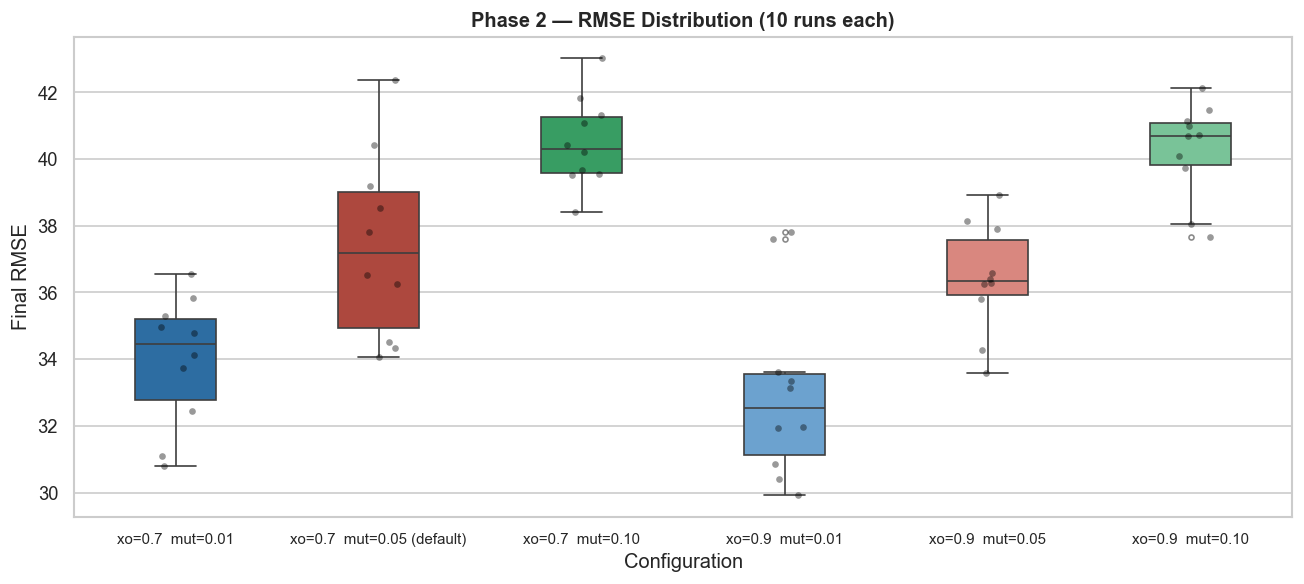

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df_pt, x="config_id", y="rmse_final",
    order=CONFIG_IDS_PT,
    hue="config_id", hue_order=CONFIG_IDS_PT,
    palette=CONFIG_COLORS_PT,
    legend=False, width=0.4,
    flierprops={"marker": ".", "alpha": 0.6},
    ax=ax,
)
sns.stripplot(
    data=df_pt, x="config_id", y="rmse_final",
    order=CONFIG_IDS_PT,
    color="black", alpha=0.4, size=4, jitter=True, ax=ax,
)

ax.set_xticks(range(len(CONFIG_IDS_PT)))
ax.set_xticklabels([CONFIG_LABELS_PT[c] for c in CONFIG_IDS_PT], fontsize=9)
ax.set_xlabel("Configuration")
ax.set_ylabel("Final RMSE")
ax.set_title("Phase 2 — RMSE Distribution (10 runs each)", fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR_PT / "boxplot_prob_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

#### Convergence Curves

Mean best RMSE at each generation (± 1 std band), averaged across 10 runs.

**Solid lines** = xo_prob=0.7 | **dashed lines** = xo_prob=0.9, makes it easy to see whether increasing crossover probability consistently shifts convergence across all mutation levels.

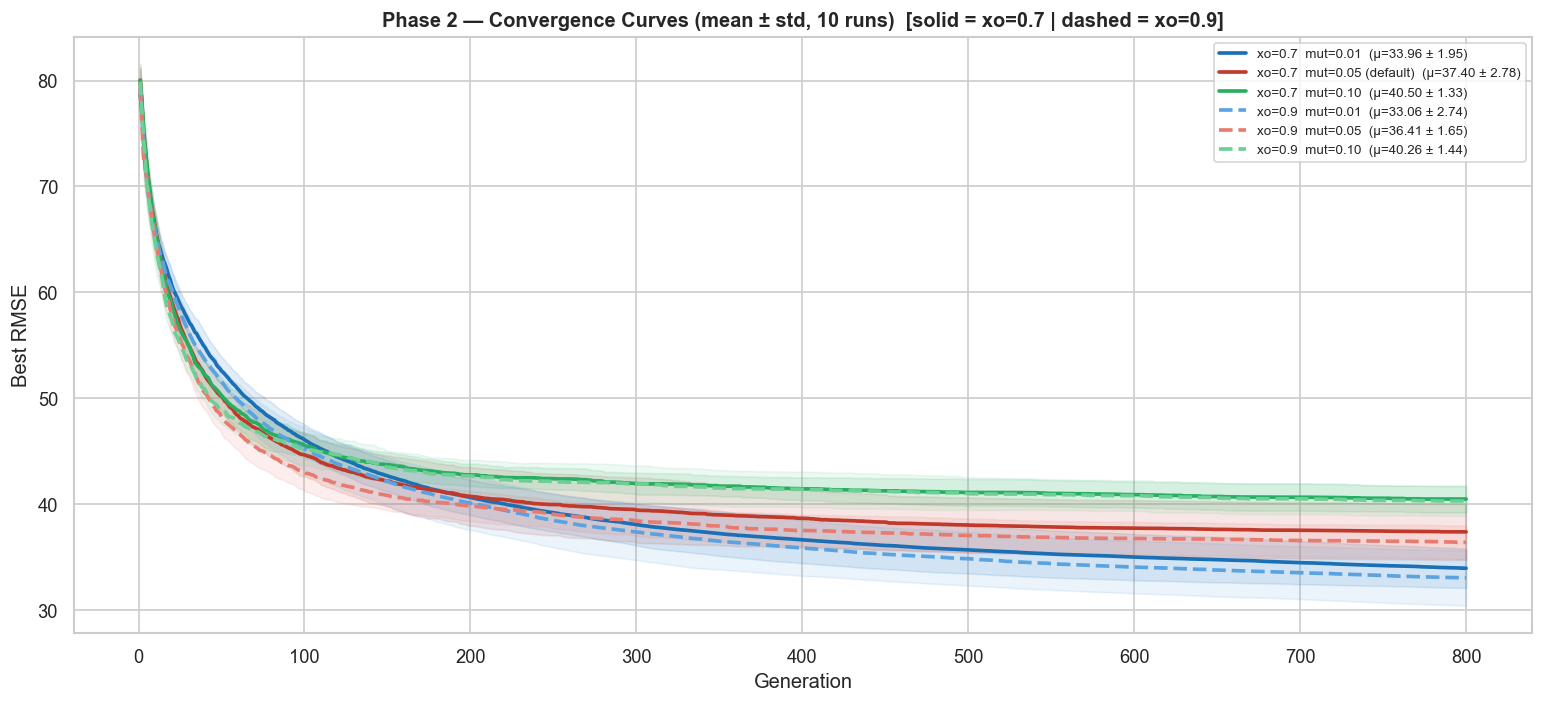

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

for cfg_id in CONFIG_IDS_PT:
    group  = df_pt[df_pt["config_id"] == cfg_id]
    if group.empty:
        continue
    curves = np.array(group["fitness_curve"].tolist())
    mean_c = curves.mean(axis=0)
    std_c  = curves.std(axis=0)
    gens   = np.arange(1, len(mean_c) + 1)
    row    = summary_pt.loc[cfg_id]
    ls     = "-" if group["xo_prob"].iloc[0] == 0.7 else "--"
    ax.plot(gens, mean_c,
            color=CONFIG_COLORS_PT[cfg_id], linewidth=2.2, linestyle=ls,
            label=f"{CONFIG_LABELS_PT[cfg_id]}  (μ={row['rmse_mean']:.2f} ± {row['rmse_std']:.2f})")
    ax.fill_between(gens, mean_c - std_c, mean_c + std_c,
                    color=CONFIG_COLORS_PT[cfg_id], alpha=0.12)

ax.set_xlabel("Generation")
ax.set_ylabel("Best RMSE")
ax.set_title(
    "Phase 2 — Convergence Curves (mean ± std, 10 runs)  [solid = xo=0.7 | dashed = xo=0.9]",
    fontweight="bold"
)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(BASE_DIR_PT / "convergence_prob_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

#### Heatmap — Mean RMSE Grid (xo_prob × mut_prob)

Compact view of the entire 2×3 grid: each cell shows the mean final RMSE for that (xo_prob, mut_prob) combination. Cross-factor patterns are immediately visible. The best-performing cell is outlined in navy.

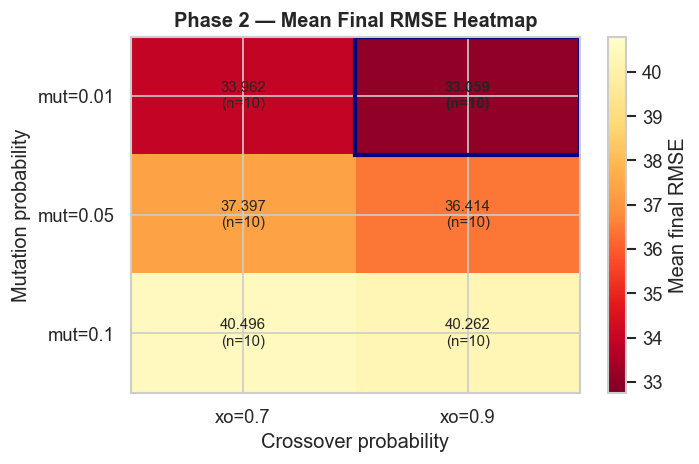

In [19]:
heatmap_rows = []
for cfg in CONFIGS_PT:
    cfg_df = df_pt[df_pt["config_id"] == cfg["id"]]
    if cfg_df.empty:
        continue
    heatmap_rows.append({
        "xo_prob":   cfg["xo_prob"],
        "mut_prob":  cfg["mut_prob"],
        "mean_rmse": round(float(cfg_df["rmse_final"].mean()), 4),
        "n":         len(cfg_df),
    })

hm_df  = pd.DataFrame(heatmap_rows)
pivot  = hm_df.pivot(index="mut_prob", columns="xo_prob", values="mean_rmse")
n_piv  = hm_df.pivot(index="mut_prob", columns="xo_prob", values="n")

winner_mut = hm_df.loc[hm_df["mean_rmse"].idxmin(), "mut_prob"]
winner_xo  = hm_df.loc[hm_df["mean_rmse"].idxmin(), "xo_prob"]

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto",
               vmin=pivot.values.min() - 0.3, vmax=pivot.values.max() + 0.3)

for i, mut in enumerate(pivot.index):
    for j, xo in enumerate(pivot.columns):
        val = pivot.loc[mut, xo]
        n   = n_piv.loc[mut, xo] if (mut in n_piv.index and xo in n_piv.columns) else "?"
        is_winner = (xo == winner_xo and mut == winner_mut)
        ax.text(j, i, f"{val:.3f}\n(n={n})",
                ha="center", va="center", fontsize=9,
                fontweight="bold" if is_winner else "normal")
        if is_winner:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       linewidth=2.5, edgecolor="navy", facecolor="none"))

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"xo={v}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"mut={v}" for v in pivot.index])
ax.set_xlabel("Crossover probability")
ax.set_ylabel("Mutation probability")
ax.set_title("Phase 2 — Mean Final RMSE Heatmap", fontweight="bold")
plt.colorbar(im, ax=ax, label="Mean final RMSE")
plt.tight_layout()
plt.savefig(BASE_DIR_PT / "heatmap_prob_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusions

**Theoretical expectations vs observed results**

Before running the grid, the Schema Theorem and BBH suggested a clear prior:
- **xo=0.9, mut=0.05** most likely best: strong recombination activates BBH, balanced mutation (schema survival ~0.75) preserves building blocks without over-constraining exploration.
- **xo=0.7, mut=0.01** second: high schema preservation (survival ~0.95) reduces disruption but risks premature convergence on a high-dimensional landscape.
- **xo=0.9, mut=0.10** uncertain: heavy mutation (survival ~0.50) destroys half of all schemata per generation.

**What the data shows**

The heatmap confirms that `mut_prob` is the dominant factor: RMSE increases monotonically as mutation rises from 0.01 to 0.10, regardless of crossover level. `xo_prob` has a secondary but consistent effect, `xo=0.9` outperforms `xo=0.7` at every mutation level.

Key observations:
- The effect of `mut_prob` is dominant across both crossover levels, consistent with the Schema Theorem prediction.
- The effect of `xo_prob` interacts with `mut_prob` as expected from the BBH: higher crossover amplifies building-block combination only when mutation is not already destroying the blocks.

The winner is **`xo=0.9, mut=0.01`** (mean RMSE = 33.059), which partially contradicts the prior, low mutation dominates over the balanced `mut=0.05` case, suggesting that schema preservation matters more than exploration once a good operator set is fixed.

The **final configuration** carried into the next sections (Final Run and Island GA) is therefore fully determined:

`tournament k=5 | uniform crossover | gaussian mutation | xo_prob=0.9 | mut_prob=0.01`

---

# 6. Final Run and Island GA Analysis

## 6.1 Final Configuration Run

This section evaluates the optimal configuration identified through the preceding phases of systematic experimentation.

**How we got here:** The grid search over 30 operator combinations identified tournament k=5, uniform crossover, and gaussian mutation as the best operator set. The probability tuning over a 2×3 grid then found `xo_prob=0.9` and `mut_prob=0.01` as the optimal probability pair.

Running 10 independent trials at **5 000 generations** (vs 800 in the search phases) gives the algorithm more time to converge and yields a reliable estimate of the best achievable RMSE under this configuration.

| Parameter | Value |
|-----------|-------|
| Selection | Tournament k=5 |
| Crossover | Uniform, xo\_prob=0.9 |
| Mutation  | Gaussian, mut\_prob=0.01 |
| pop\_size  | 100 |
| max\_gen   | 5 000 |
| elitesize | 2 |

&nbsp;

> **[`run_final.py`](experiments/run_final.py)**  
*Runs the best-found configuration for 10 independent trials at 5 000 generations and population 100, with per-generation diversity tracking.*

---

## 6.2 Island GA

The Island Model Genetic Algorithm partitions the population into several independent sub-populations (*islands*) that evolve in parallel and periodically exchange individuals through *migration*.

**How it works:**
1. The total population budget (100 individuals) is split into **4 islands of 25 individuals** each.
2. Each island runs a standard GA independently for a fixed number of generations (*migration interval* = 20).
3. After each interval, the **best individual** from each island migrates to the next island in the ring, replacing the worst resident.
4. This cycle repeats until the maximum number of generations is reached.

The key intuition is that **isolation fosters diversity**: sub-populations explore different regions of the fitness landscape independently, reducing the risk of premature convergence. Periodic migration then propagates promising solutions across islands without fully merging the gene pools.

**References:**
- Whitley D. et al. (1999). *Island model genetic algorithms and linearly separable problems.*
- Cantú-Paz E. (1998). *A survey of parallel genetic algorithms.*

| Aspect | Standard GA | Island GA |
|--------|------------|----------|
| Population structure | 1 × 100 | 4 × 25 |
| Selection scope | Global (100 ind.) | Per island (25 ind.) |
| Migration | None | Ring topology, every 20 gen, size=1 (best individual) |
| Operators | Tournament k=5 \| Uniform xo \| Gaussian mut | Identical |
| Probabilities | xo\_prob=0.9, mut\_prob=0.01 | Identical |
| Generations | 5 000 | 5 000 |
| Runs | 10 | 10 |

&nbsp;

> **[`run_island_model.py`](experiments/run_island_model.py)**  
*Implements the Island GA with 4 subpopulations of 25 individuals each, evolving independently and exchanging the best individual via ring-topology migration every 20 generations.*

---

## 6.3 Results Analysis

This section compares the Standard GA and the Island GA under identical operator and probability settings. Both run for 5 000 generations with 10 independent trials each, the only difference is population structure.

The configuration used here is not arbitrary: it is the result of the systematic optimisation carried out in Sections 2–5. The question is whether splitting the same population budget into isolated sub-populations with periodic migration produces better final results than a single well-tuned population.

In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ISLAND_DIR = Path("results/island_model")
FINAL_DIR  = Path("results/final")
DATA_DIR   = Path("data")
OUT_DIR    = Path("results/final")

SOURCES = [
    {"id": "standard_ga",  "label": "Standard GA",  "color": "#2980b9",
     "logs_dir": FINAL_DIR  / "logs", "images_dir": FINAL_DIR  / "images"},
    {"id": "island_model", "label": "Island GA",     "color": "#8e44ad",
     "logs_dir": ISLAND_DIR / "logs", "images_dir": ISLAND_DIR / "images"},
]
SOURCE_IDS    = [s["id"]               for s in SOURCES]
SOURCE_LABELS = {s["id"]: s["label"]   for s in SOURCES}
SOURCE_COLORS = {s["id"]: s["color"]   for s in SOURCES}
SOURCE_IMGS   = {s["id"]: s["images_dir"] for s in SOURCES}

#### Load Data

In [21]:
records = []
for src in SOURCES:
    logs_dir = src["logs_dir"]
    if not logs_dir.exists():
        print(f"WARNING: logs not found for '{src['id']}' → {logs_dir}")
        continue
    for fpath in sorted(logs_dir.glob("run*.json")):
        d = json.loads(fpath.read_text(encoding="utf-8"))
        records.append({
            "source_id":     src["id"],
            "run":           int(d["run"]),
            "rmse_initial":  float(d["rmse_initial"]),
            "rmse_final":    float(d["rmse_final"]),
            "fitness_curve": d["fitness_curve"],
        })

df = pd.DataFrame(records)

summary = (
    df.groupby("source_id")
    .agg(
        n          =("rmse_final", "count"),
        rmse_mean  =("rmse_final", "mean"),
        rmse_std   =("rmse_final", "std"),
        rmse_min   =("rmse_final", "min"),
        rmse_max   =("rmse_final", "max"),
        rmse_median=("rmse_final", "median"),
    )
    .reindex(SOURCE_IDS)
    .round(4)
)
print(f"Loaded {len(df)} runs ({df.groupby('source_id')['run'].count().to_dict()})")
summary

Loaded 20 runs ({'island_model': 10, 'standard_ga': 10})


,n,rmse_mean,rmse_std,rmse_min,rmse_max,rmse_median
source_id,,,,,,
standard_ga,10,28.2181,1.7917,25.9648,32.2575,28.0732
island_model,10,29.4276,1.2666,27.8608,31.6271,29.2383


#### RMSE Distribution — Box Plot

Final RMSE distribution across 10 runs per configuration, individual dots are single runs, their vertical spread shows how consistent the algorithm is across different random seeds, a lower median with a narrow box means the approach is both better on average and more reliable.

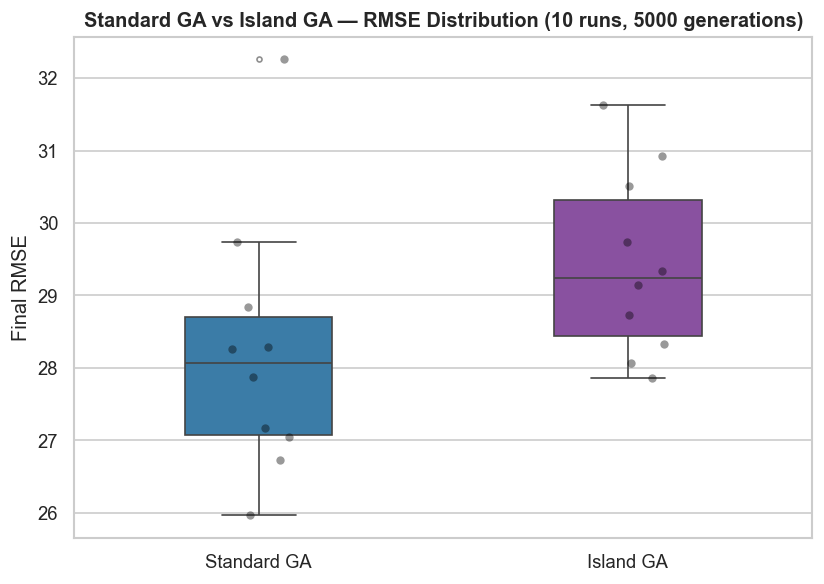

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x="source_id", y="rmse_final",
    order=SOURCE_IDS,
    hue="source_id", hue_order=SOURCE_IDS,
    palette=SOURCE_COLORS,
    legend=False, width=0.4,
    flierprops={"marker": ".", "alpha": 0.6},
    ax=ax,
)
sns.stripplot(
    data=df, x="source_id", y="rmse_final",
    order=SOURCE_IDS,
    color="black", alpha=0.4, size=5, jitter=True, ax=ax,
)

ax.set_xticks(range(len(SOURCE_IDS)))
ax.set_xticklabels([SOURCE_LABELS[sid] for sid in SOURCE_IDS], fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Final RMSE")
ax.set_title(
    "Standard GA vs Island GA — RMSE Distribution (10 runs, 5000 generations)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "boxplot_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#### Convergence Curves

Mean best RMSE per generation across 5 000 generations (± 1 std band, averaged over 10 runs).

With 5 000 generations the convergence profile reveals more than just the final value: we can see whether the island model's diversity-preservation mechanism produces a slower but more sustained improvement in the second half of the run, or whether both approaches plateau at similar points.

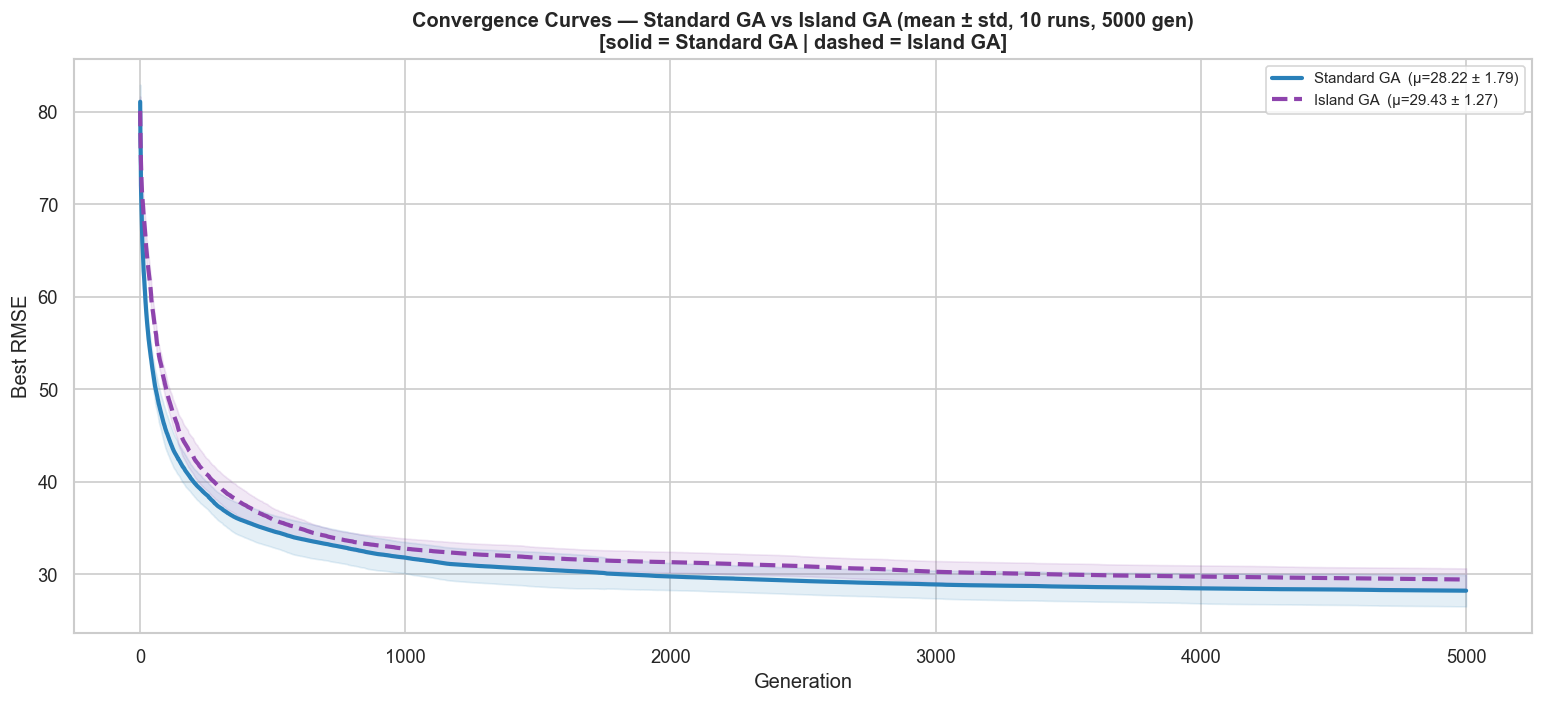

In [23]:
fig, ax = plt.subplots(figsize=(13, 6))

for src_id in SOURCE_IDS:
    group = df[df["source_id"] == src_id]
    if group.empty:
        continue
    curves = np.array(group["fitness_curve"].tolist())
    mean_c = curves.mean(axis=0)
    std_c  = curves.std(axis=0)
    gens   = np.arange(1, len(mean_c) + 1)
    row    = summary.loc[src_id]
    ls     = "-" if src_id == "standard_ga" else "--"
    ax.plot(gens, mean_c,
            color=SOURCE_COLORS[src_id], linewidth=2.5, linestyle=ls,
            label=f"{SOURCE_LABELS[src_id]}  (μ={row['rmse_mean']:.2f} ± {row['rmse_std']:.2f})")
    ax.fill_between(gens, mean_c - std_c, mean_c + std_c,
                    color=SOURCE_COLORS[src_id], alpha=0.12)

ax.set_xlabel("Generation")
ax.set_ylabel("Best RMSE")
ax.set_title(
    "Convergence Curves — Standard GA vs Island GA (mean ± std, 10 runs, 5000 gen)\n"
    "[solid = Standard GA | dashed = Island GA]",
    fontweight="bold",
)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(OUT_DIR / "convergence_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#### Diversity Analysis

Phenotypic diversity is measured as the **standard deviation of all individual fitness values** in the population at each generation. A high value means individuals span a wide range of RMSE scores, the population is still exploring. A drop towards zero signals convergence: all individuals have clustered around similar fitness.

Comparing diversity profiles between the two architectures reveals a structural difference:

- **Standard GA**: global selection pressure acts on all 100 individuals simultaneously, tending to collapse diversity relatively quickly once promising regions are found.
- **Island GA**: each island of 25 individuals evolves in isolation. Because diversity here is measured across the full 100-individual pool, isolated sub-populations exploring different regions produce a structurally higher global diversity. Periodic migration injects fresh material without fully merging the gene pools.

A configuration that maintains diversity longer is less likely to converge prematurely and more likely to keep improving in later generations.

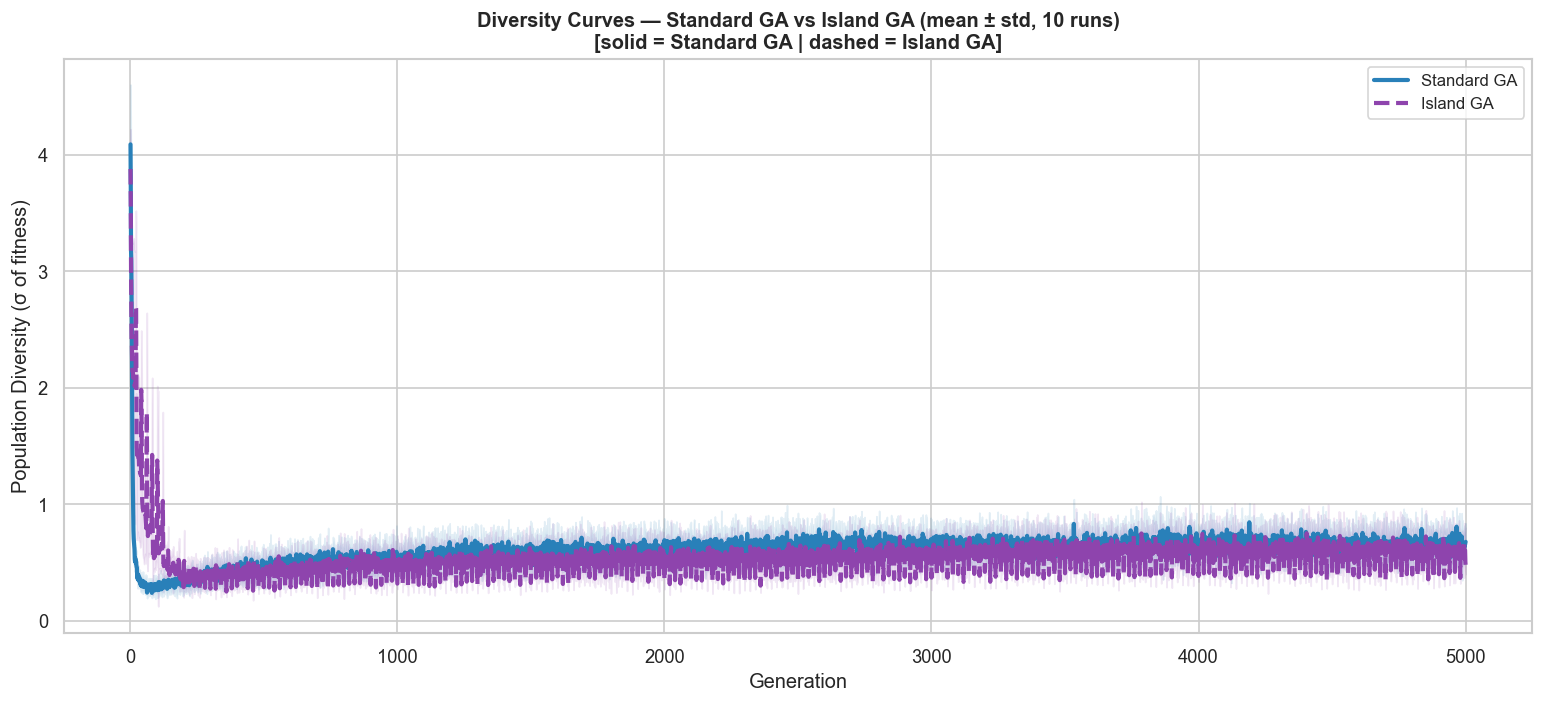

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))

for src in SOURCES:
    src_id   = src["id"]
    logs_dir = src["logs_dir"]
    curves   = []
    if logs_dir.exists():
        for fpath in sorted(logs_dir.glob("run*.json")):
            d = json.loads(fpath.read_text(encoding="utf-8"))
            if d.get("diversity_curve"):
                curves.append(d["diversity_curve"])
    if not curves:
        print(f"No diversity curves for {src_id}")
        continue
    arr    = np.array(curves)
    mean_d = arr.mean(axis=0)
    std_d  = arr.std(axis=0)
    gens   = np.arange(1, len(mean_d) + 1)
    ls     = "-" if src_id == "standard_ga" else "--"
    ax.plot(gens, mean_d,
            color=SOURCE_COLORS[src_id], linewidth=2.5, linestyle=ls,
            label=f"{SOURCE_LABELS[src_id]}")
    ax.fill_between(gens, mean_d - std_d, mean_d + std_d,
                    color=SOURCE_COLORS[src_id], alpha=0.12)

ax.set_xlabel("Generation")
ax.set_ylabel("Population Diversity (σ of fitness)")
ax.set_title(
    "Diversity Curves — Standard GA vs Island GA (mean ± std, 10 runs)\n"
    "[solid = Standard GA | dashed = Island GA]",
    fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "diversity_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#### Visual Comparison — Best Result per Configuration

The best image produced across all 10 runs for each configuration, alongside the original target, lower RMSE corresponds to a closer pixel-level match.

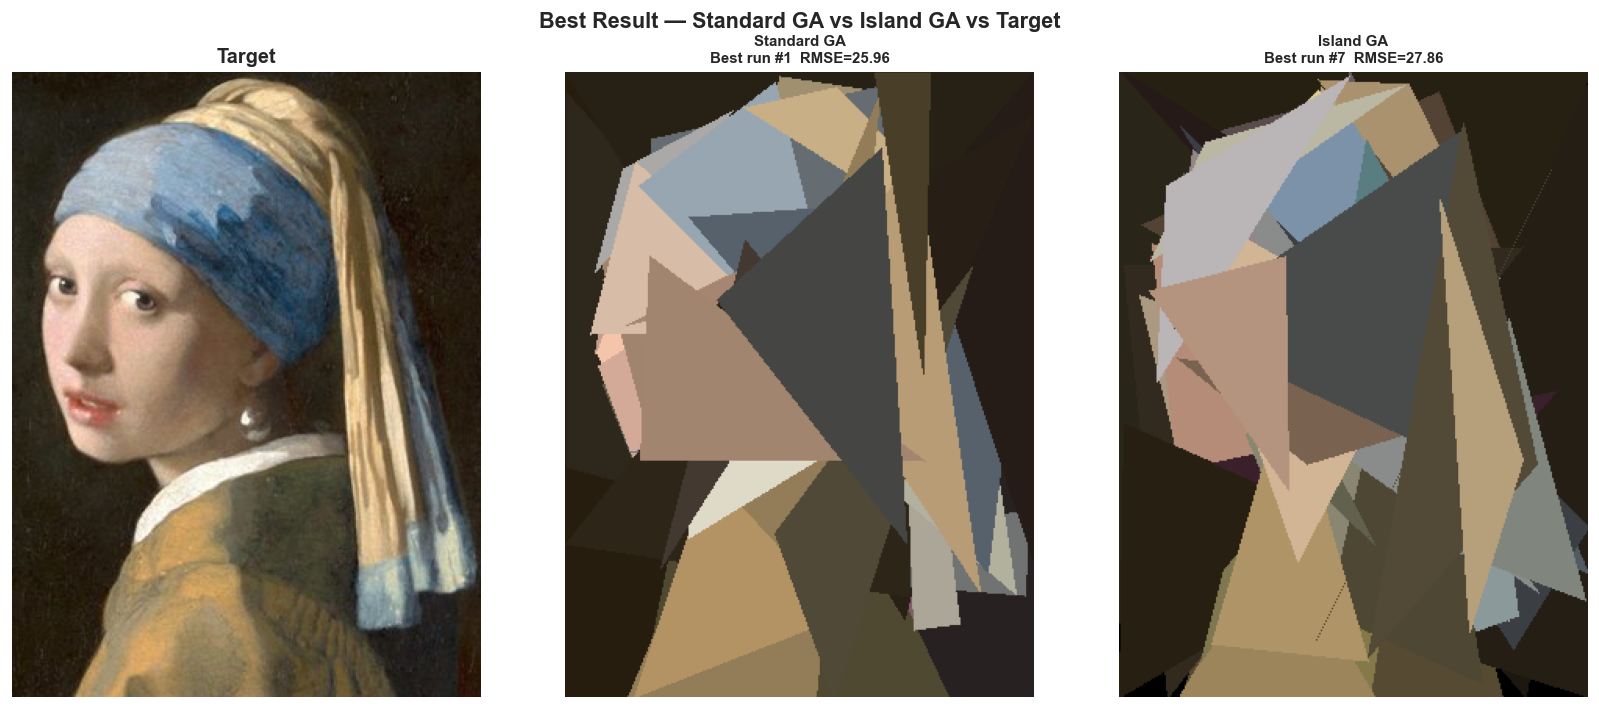

In [25]:
target = Image.open(DATA_DIR / "girl_pearl_earring.png")

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].imshow(target)
axes[0].set_title("Target", fontweight="bold")
axes[0].axis("off")

for ax, src_id in zip(axes[1:], SOURCE_IDS):
    src_df = df[df["source_id"] == src_id]
    if src_df.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue
    best_row = src_df.loc[src_df["rmse_final"].idxmin()]
    best_run = int(best_row["run"])
    img_path = SOURCE_IMGS[src_id] / f"run{best_run:02d}.png"
    try:
        ax.imshow(Image.open(img_path))
    except FileNotFoundError:
        ax.text(0.5, 0.5, "image not found", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(
        f"{SOURCE_LABELS[src_id]}\nBest run #{best_run}  RMSE={best_row['rmse_final']:.2f}",
        fontsize=9, fontweight="bold",
    )
    ax.axis("off")

plt.suptitle("Best Result — Standard GA vs Island GA vs Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "best_results_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Conclusions

**What the data shows**

Both configurations use identical operators and probabilities, the only structural difference is population architecture. Across 10 independent runs at 5 000 generations:

| | Standard GA | Island GA |
|---|---|---|
| Mean RMSE | **28.22** | 29.43 |
| Std | 1.79 | 1.27 |
| Best run | **25.96** | 27.86 |

The Standard GA outperforms the Island GA on mean and best-run RMSE, while the Island GA is more consistent (lower std).

**Interpretation**

The single large population (100 individuals) with low mutation maintains sufficient diversity over 5 000 generations without requiring architectural isolation. With very low mutation, the main driver of diversity is crossover recombination, which operates most effectively when selection pools are large, exactly what the standard single-population setup provides.

The Island GA's smaller per-island population (25 individuals) reduces the effective selection pressure per island without delivering a compensating diversity benefit in this setting: at , each island may converge prematurely before migration can spread useful variation across the ring. The Island GA is more consistent across runs (lower std), suggesting its architecture does reduce variance, but at the cost of mean performance.

**Conclusion:** for this problem and configuration, the well-tuned single-population GA is sufficient, the Island GA adds consistency but not higher peak performance.